# Running Regression

## Imports

In [5]:
#This is what I should use <- OOP based subject functions <-  much eeasier to work with than other data representations
#This file
import numpy as np
#from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk
#import tkinter as tk
from tqdm import tqdm
import torch
from helpers.helpers import *
from helpers.constants import *
from helpers.Subject import Subject
from helpers.ridge import RidgePerElectrode
from concurrent.futures import ThreadPoolExecutor
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split, KFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GroupShuffleSplit
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm
#from helpers.Sub_test import Mne_Subject
import matplotlib as plt

In [6]:
subject_obj = np.load("S8_object.npy", allow_pickle=True).item()

In [10]:
subject_obj.trigger_frame['sentence'][10]

{'sen_field': {'w1': 'the',
  'w2': 'rocks',
  'w3': 'broke',
  'w4': 'windows',
  'imageFile': '/Users/klab/Desktop/4WT-English/word-sentence-lists/sentence-pics/the-rocks-broke-windows.jpg',
  'falseImageFile': '/Users/klab/Desktop/4WT-English/word-sentence-lists/sentence-pics/the-teachers-handed-papers.jpg',
  'relatedImage': 1,
  'sentenceType': 'GS',
  'w1Type': 'det',
  'w2Type': 'nna',
  'w3Type': 'ver',
  'w4Type': 'nno',
  'modality': 'v'}}

In [ ]:
#we need to blow out the sentenceType field <- "GS"

## Global Functions for Trigger Alignment and running all subjects

In [10]:
def align_triggers_from_system_time(subject):
    """
    Use system timestamps instead of Var1 since Var1 extends beyond recording
    """
    triggers_df = subject.prepare_trigger_dataframe()
    triggers_df = subject.correct_trigger_errors(triggers_df)
    
    fs = int(subject.hdr_frame['frequency'][0])
    
    # Convert system time (seconds) to sample indices
    # Assuming recording started at the same time as experiment
    triggers_df['event_samples'] = (triggers_df['system_timePreOnset'] * fs).astype(int)
    
    print(f"System time range: {triggers_df['system_timePreOnset'].min():.2f}s to {triggers_df['system_timePreOnset'].max():.2f}s")
    print(f"Converted to samples: {triggers_df['event_samples'].min()} to {triggers_df['event_samples'].max()}")
    
    # Filter valid events within recording bounds
    data_samples = subject.record_filter.shape[1]
    valid_mask = (triggers_df['event_samples'] >= 0) & (triggers_df['event_samples'] < data_samples)
    
    num_invalid = (~valid_mask).sum()
    print(f"⚠️ {num_invalid} events fall outside recording bounds and will be excluded")
    
    triggers_df = triggers_df[valid_mask].reset_index(drop=True)
    print(f"Retained {len(triggers_df)} valid triggers")
    
    return triggers_df

In [11]:
def ridge_per_electrode_optimized(
    X, y, groups=None, alpha_range=None, n_folds=10, 
    random_state=42, use_pca=True, n_components=50
):
    """
    Optimized ridge regression - much faster than original.
    
    Speed improvements:
    - Reduced default n_folds from 10 to 5
    - Vectorized cross-validation across electrodes
    - Efficient numpy operations
    """
    
    if alpha_range is None:
        alpha_range = np.logspace(-3, 1, 5)  # Reduced from 10 to 5 alphas
    
    # Train/test split
    if groups is not None:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state) #Try changing test size
        train_idx, test_idx = next(splitter.split(X, y, groups=groups))
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=random_state
        )
    
    # Optional PCA
    scaler, pca = None, None
    if use_pca:
        print(f"Applying PCA ({n_components} components)...")
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        pca = PCA(n_components=n_components, random_state=random_state)
        X_train = pca.fit_transform(X_train_scaled)
        X_test = pca.transform(X_test_scaled)
        print(f"  Variance explained: {pca.explained_variance_ratio_.sum():.3f}")
    
    # Fit model - FIXED: use RidgePerElectrode instead of FastRidgePerElectrode
    model = RidgePerElectrode(
        alpha_range=alpha_range,
        n_folds=n_folds,
        random_state=random_state
    )
    model.fit(X_train, y_train)
    
    # Evaluate
    train_metrics = model.evaluate(X_train, y_train)
    test_metrics = model.evaluate(X_test, y_test)
    
    # Results
    n_electrodes = y.shape[1]
    results_df = pd.DataFrame({
        "electrode": [f"electrode_{i}" for i in range(n_electrodes)],
        "best_alpha": model.best_alphas_,
        "train_MSE": train_metrics['mse'],
        "test_MSE": test_metrics['mse'],
        "train_R": train_metrics['pearson_r'],
        "test_R": test_metrics['pearson_r']
    })
    
    return results_df, model, scaler, pca

In [12]:
def sentence_pool(): # start adapting this so I can run every participant and get group stats
#Dictionary to store subjects
    sub_obj_dict = {} 
    dataframes = []
    for i in range(1,18):
        #Initialize new subject
        curr_sub = f"S{i}"
        print("On Subject", curr_sub)
        print()
        curr_direc = directory[i-1]
        sub_obj_dict[curr_sub] = Subject(curr_sub,i,curr_direc)

        #Run initalization functions
        sub_obj_dict[curr_sub].load_behav_mat()
        sub_obj_dict[curr_sub].convert_behav_mats()
        print("Behavioral Data Loaded")
        print()
        curr_sentence = sub_obj_dict[curr_sub].create_sentence_frame()
        curr_sentence['sub_id'] = i
        dataframes.append(curr_sentence)
        print("Dataframe Created and Appended")
        print() 

    total_sentence = pd.concat(dataframes, ignore_index = True)
    return total_sentence

In [13]:
def prepare_sliding_window_X_y(features_df, embeddings, trial_df, 
                                time_window='consolidation', 
                                use_z_power=True):
    """
    1. Filters time windows to the desired range (e.g., 200-1000ms)
    2. Averages power across those windows for each trial
    3. Creates y matrix: (n_trials, n_electrodes)
    4. Matches trials to embeddings for X matrix
    """
    
    # Get electrode columns
    power_cols = [c for c in features_df.columns if 'electrode' in c and 'power' in c]
    if use_z_power:
        power_cols = [c for c in power_cols if 'z_power' in c]
    else:
        power_cols = [c for c in power_cols if 'z_power' not in c]
    
    # Define time window
    if time_window == 'consolidation':
        start_ms, end_ms = 200, 1000
    elif time_window == 'full':
        start_ms, end_ms = features_df['time_start_ms'].min(), features_df['time_end_ms'].max()
    else:
        start_ms, end_ms = time_window
    
    # Filter to time window
    mask = (features_df['time_start_ms'] >= start_ms) & (features_df['time_end_ms'] <= end_ms)
    windowed_df = features_df[mask].copy()
    
    # CRITICAL: Average across windows within each trial
    trial_features = windowed_df.groupby('trial_idx')[power_cols].mean().reset_index()
    
    # Extract y (neural features)
    y = trial_features[power_cols].values  # (n_trials, n_electrodes)
    
    # Get trial indices
    valid_trials = trial_features['trial_idx'].values
    
    # Match trials to embeddings
    X = embeddings[valid_trials]  # This assumes embeddings are indexed by trial
    
    groups = valid_trials
    
    return X, y, groups

In [14]:
def get_embeddings(sentences, model_name, batch_size=128, method="concat", max_words=4):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()
    
    is_gpt = "gpt" in model_name.lower()
    effective_max_words = max_words - 1 if is_gpt else max_words
    
    # Pre-allocate array for better memory efficiency
    num_samples = len(sentences)
    # We'll determine embedding size from first batch
    embeddings_list = []
    
    for i in tqdm(range(0, num_samples, batch_size)):
        batch = sentences[i:i + batch_size]
        
        # More efficient tokenization
        inputs = tokenizer(
            batch, 
            return_tensors="pt", 
            padding=True, 
            truncation=True, 
            max_length=50
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            hidden = outputs.last_hidden_state
            
            # Vectorized slicing and padding
            n_words = min(hidden.shape[1], effective_max_words)
            word_emb = hidden[:, :n_words, :]
            
            if n_words < effective_max_words:
                pad_size = (hidden.shape[0], effective_max_words - n_words, hidden.shape[2])
                word_emb = torch.cat([word_emb, torch.zeros(pad_size, device=device)], dim=1)
            
            # Reshape and move to CPU in one operation
            batch_emb = word_emb.reshape(word_emb.shape[0], -1).cpu().numpy()
            embeddings_list.append(batch_emb)
    
    # Concatenate once at the end instead of extending list
    return np.vstack(embeddings_list)

In [15]:
#Create the y variable <- the trials I want to go over
def extract_y_from_record(trial_df, record, pre=4100, post=5100): #do the full window for now
    y = []
    for sample in trial_df.iloc[:,11].tolist():
        start = int(sample + pre)
        end = int(sample + post)
        y_window = record[:, start:end]
        y.append(np.mean(y_window, axis=1))  # average gamma per electrode
    return np.array(y)


In [16]:
def run_ridge_regression_sliding_window(features_df, bert_embeddings, gpt_embeddings, 
                                       trial_df, time_window='consolidation',
                                       use_z_power=True, alpha_range=None, n_folds=10,
                                       n_jobs=-1):
    """
    Run ridge regression for sliding window features.
    """
    
    if alpha_range is None:
        alpha_range = np.logspace(-4, 1, 10)
    
    # Step 1: Prepare data
    X_bert, y, groups = prepare_sliding_window_X_y(
        features_df, bert_embeddings, trial_df, time_window, use_z_power
    )
    X_gpt, _, _ = prepare_sliding_window_X_y(
        features_df, gpt_embeddings, trial_df, time_window, use_z_power
    )
    
    # Step 2: Call ridge_per_electrode_optimized (NOT ridge_per_electrode_improved)
    print("\n=== Running BERT ===")
    bert_results, bert_model, bert_scaler, bert_pca = ridge_per_electrode_optimized(
        X_bert, y, groups=groups, alpha_range=alpha_range, n_folds=n_folds,
        use_pca=False  # Remove use_torch and n_jobs - not needed with optimized version
    )
    
    print("\n=== Running GPT ===")
    gpt_results, gpt_model, gpt_scaler, gpt_pca = ridge_per_electrode_optimized(
        X_gpt, y, groups=groups, alpha_range=alpha_range, n_folds=n_folds,
        use_pca=False  # Remove use_torch and n_jobs - not needed with optimized version
    )
    
    return {
        'bert_results': bert_results,
        'gpt_results': gpt_results,
        'bert_model': bert_model,
        'gpt_model': gpt_model,
        'y': y,
        'groups': groups
    }

In [17]:
def plot_time_resolved_performance(features_df, bert_embeddings, gpt_embeddings, 
                                   trial_df, time_windows, use_z_power=True):
    """
    Plot how model performance changes across time windows.
    
    Parameters:
    -----------
    time_windows : list of tuples [(start1, end1), (start2, end2), ...]
    """
    
    results = []
    
    for start_ms, end_ms in time_windows:
        print(f"\nProcessing {start_ms}-{end_ms}ms...")
        
        # Run regression for this time window
        result = run_ridge_regression_sliding_window(
            features_df, bert_embeddings, gpt_embeddings, trial_df,
            time_window=(start_ms, end_ms), use_z_power=use_z_power
        )
        
        results.append({
            'time_center': (start_ms + end_ms) / 2,
            'bert_mean_r': result['bert_results']['test_R'].mean(),
            'gpt_mean_r': result['gpt_results']['test_R'].mean(),
            'bert_std_r': result['bert_results']['test_R'].std(),
            'gpt_std_r': result['gpt_results']['test_R'].std()
        })
    
    df = pd.DataFrame(results)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.errorbar(df['time_center'], df['bert_mean_r'], 
                yerr=df['bert_std_r'], label='BERT', 
                marker='o', capsize=5, linewidth=2)
    ax.errorbar(df['time_center'], df['gpt_mean_r'], 
                yerr=df['gpt_std_r'], label='GPT-2-XL', 
                marker='s', capsize=5, linewidth=2)
    
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5, label='Word onset')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    
    ax.set_xlabel('Time from word onset (ms)', fontsize=12)
    ax.set_ylabel('Mean Pearson R (across electrodes)', fontsize=12)
    ax.set_title('Time-Resolved Model Performance', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, df






In [18]:
def plot_per_word_comparison(features_df, bert_embeddings, gpt_embeddings):
    """
    Compare performance across the 4 words in the sentence.
    """
    
    results = []
    
    for word_pos in range(1, 5):
        result = run_ridge_regression_per_word(
            features_df, bert_embeddings, gpt_embeddings, word_position=word_pos
        )
        
        results.append({
            'word': word_pos,
            'bert_mean_r': result['bert_results']['test_R'].mean(),
            'gpt_mean_r': result['gpt_results']['test_R'].mean()
        })
    
    df = pd.DataFrame(results)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(df))
    width = 0.35
    
    ax.bar(x - width/2, df['bert_mean_r'], width, label='BERT', alpha=0.8)
    ax.bar(x + width/2, df['gpt_mean_r'], width, label='GPT-2-XL', alpha=0.8)
    
    ax.set_xlabel('Word Position', fontsize=12)
    ax.set_ylabel('Mean Pearson R', fontsize=12)
    ax.set_title('Model Performance by Word Position', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Word {i}' for i in range(1, 5)])
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    return fig, df



    return fig, comparison

In [19]:
def plot_per_word_comparison(features_df, bert_embeddings, gpt_embeddings):
    """
    Compare performance across the 4 words in the sentence.
    """
    
    results = []
    
    for word_pos in range(1, 5):
        result = run_ridge_regression_per_word(
            features_df, bert_embeddings, gpt_embeddings, word_position=word_pos
        )
        
        results.append({
            'word': word_pos,
            'bert_mean_r': result['bert_results']['test_R'].mean(),
            'gpt_mean_r': result['gpt_results']['test_R'].mean()
        })
    
    df = pd.DataFrame(results)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(df))
    width = 0.35
    
    ax.bar(x - width/2, df['bert_mean_r'], width, label='BERT', alpha=0.8)
    ax.bar(x + width/2, df['gpt_mean_r'], width, label='GPT-2-XL', alpha=0.8)
    
    ax.set_xlabel('Word Position', fontsize=12)
    ax.set_ylabel('Mean Pearson R', fontsize=12)
    ax.set_title('Model Performance by Word Position', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Word {i}' for i in range(1, 5)])
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    return fig, df

In [20]:
def plot_electrode_brain_map(results, electrode_positions=None):
    """
    Create a brain map showing which electrodes are best predicted.
    
    Parameters:
    -----------
    results : dict from run_ridge_regression_*
    electrode_positions : DataFrame with columns ['electrode', 'x', 'y', 'z', 'region']
    """
    
    bert_results = results['bert_results']
    gpt_results = results['gpt_results']
    
    # Combine results
    comparison = pd.DataFrame({
        'electrode': bert_results['electrode'],
        'bert_r': bert_results['test_R'],
        'gpt_r': gpt_results['test_R'],
        'difference': bert_results['test_R'] - gpt_results['test_R']
    })
    
    if electrode_positions is not None:
        comparison = comparison.merge(electrode_positions, on='electrode')
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # BERT performance
    ax = axes[0, 0]
    scatter = ax.scatter(comparison.index, comparison['bert_r'], 
                        c=comparison['bert_r'], cmap='viridis', s=100)
    ax.set_xlabel('Electrode Index')
    ax.set_ylabel('Pearson R')
    ax.set_title('BERT Performance per Electrode')
    plt.colorbar(scatter, ax=ax)
    ax.grid(True, alpha=0.3)
    
    # GPT performance
    ax = axes[0, 1]
    scatter = ax.scatter(comparison.index, comparison['gpt_r'], 
                        c=comparison['gpt_r'], cmap='viridis', s=100)
    ax.set_xlabel('Electrode Index')
    ax.set_ylabel('Pearson R')
    ax.set_title('GPT-2-XL Performance per Electrode')
    plt.colorbar(scatter, ax=ax)
    ax.grid(True, alpha=0.3)
    
    # Difference
    ax = axes[1, 0]
    scatter = ax.scatter(comparison.index, comparison['difference'], 
                        c=comparison['difference'], cmap='RdBu_r', 
                        vmin=-comparison['difference'].abs().max(),
                        vmax=comparison['difference'].abs().max(), s=100)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Electrode Index')
    ax.set_ylabel('BERT R - GPT R')
    ax.set_title('Performance Difference (BERT - GPT)')
    plt.colorbar(scatter, ax=ax, label='Difference')
    ax.grid(True, alpha=0.3)
    
    # Histogram of differences
    ax = axes[1, 1]
    ax.hist(comparison['difference'], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('BERT R - GPT R')
    ax.set_ylabel('Number of Electrodes')
    ax.set_title('Distribution of Performance Differences')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, comparison

In [79]:
def plot_sentence_type_comparison(features_df, bert_embeddings, gpt_embeddings, trial_df):
    """
    Compare model performance across different sentence types.
    """
    
    sentence_types = features_df['sentence_type'].unique()
    results = []
    
    for sent_type in sentence_types:
        # Filter for this sentence type
        mask = features_df['sentence_type'] == sent_type
        filtered_df = features_df[mask]
        
        # Run regression
        result = run_ridge_regression_sliding_window(
            filtered_df, bert_embeddings, gpt_embeddings, trial_df
        )
        
        results.append({
            'sentence_type': sent_type,
            'bert_mean_r': result['bert_results']['test_R'].mean(),
            'gpt_mean_r': result['gpt_results']['test_R'].mean()
        })
    
    df = pd.DataFrame(results)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(df))
    width = 0.35
    
    ax.bar(x - width/2, df['bert_mean_r'], width, label='BERT', alpha=0.8)
    ax.bar(x + width/2, df['gpt_mean_r'], width, label='GPT-2-XL', alpha=0.8)
    
    ax.set_xlabel('Sentence Type', fontsize=12)
    ax.set_ylabel('Mean Pearson R', fontsize=12)
    ax.set_title('Model Performance by Sentence Type', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df['sentence_type'])
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    return fig, df

In [21]:
def create_comprehensive_report(features_df, bert_embeddings, gpt_embeddings, trial_df):
    """
    Generate a comprehensive report with all visualizations.
    """
    
    print("=" * 80)
    print("COMPREHENSIVE ANALYSIS REPORT")
    print("=" * 80)
    
    # 1. Overall performance
    print("\n1. Overall Performance (Consolidation Window)")
    result_overall = run_ridge_regression_sliding_window(
        features_df, bert_embeddings, gpt_embeddings, trial_df,
        time_window='consolidation'
    )
    
    fig1, comp1 = plot_electrode_brain_map(result_overall)
    plt.savefig('overall_performance.png', dpi=300, bbox_inches='tight')
    
    # 2. Time-resolved
    print("\n2. Time-Resolved Analysis")
    time_windows = [(t, t+200) for t in range(0, 1400, 100)]
    fig2, df2 = plot_time_resolved_performance(
        features_df, bert_embeddings, gpt_embeddings, trial_df, time_windows
    )
    plt.savefig('time_resolved.png', dpi=300, bbox_inches='tight')
    
    # 3. Per-word
    print("\n3. Per-Word Analysis")
    fig3, df3 = plot_per_word_comparison(
        features_df, bert_embeddings, gpt_embeddings
    )
    plt.savefig('per_word.png', dpi=300, bbox_inches='tight')
    
    # 4. Sentence type
    print("\n4. Sentence Type Analysis")
    fig4, df4 = plot_sentence_type_comparison(
        features_df, bert_embeddings, gpt_embeddings, trial_df
    )
    plt.savefig('sentence_type.png', dpi=300, bbox_inches='tight')
    
    print("\n" + "=" * 80)
    print("Analysis complete! Figures saved.")
    print("=" * 80)
    
    return {
        'overall': result_overall,
        'time_resolved': df2,
        'per_word': df3,
        'sentence_type': df4
    }

## Test Case: Running output for just Subject 8

In [22]:
trial_df = pd.DataFrame(np.load("S8_trial_df.npy", allow_pickle = True))
print("Getting Embeddings")
sentences_list = trial_df.iloc[:, 5].dropna().astype(str).to_list()

Getting Embeddings


In [24]:
trial_df

,0,1,2,3,4,5,6,7,8,9,10,11
0,FIXATION1_VIS,1,1,894.028258,894.057878,the wrote women poems,1,1,-1,990675,1,894028
1,WORD1_VIS,1,1,894.631268,894.656295,the wrote women poems,1,1,-1,991274,1,894631
2,WORD2_VIS,1,1,895.508225,895.539099,the wrote women poems,1,1,-1,992157,1,895508
3,WORD3_VIS,1,1,896.389503,896.422508,the wrote women poems,1,1,-1,993041,1,896389
4,WORD4_VIS,1,1,897.26978,897.306354,the wrote women poems,1,1,-1,993924,1,897269
...,...,...,...,...,...,...,...,...,...,...,...,...
6357,WORD2_AUD,1,1,10327.189425,10327.209907,the stole monkeys mangoes,8,120,-1,10423874,1,10327189
6358,WORD3_AUD,1,1,10328.091857,10328.112464,the stole monkeys mangoes,8,120,-1,10424777,1,10328091
6359,WORD4_AUD,1,1,10328.993147,10329.014504,the stole monkeys mangoes,8,120,-1,10425678,1,10328993
6360,WAIT_BEFORE_Q_AUD,1,1,10329.887687,10329.91373,the stole monkeys mangoes,8,120,-1,10426578,1,10329887


In [26]:
features_df

,0,1,2,3,4,5,6,7,8,9,...,200,201,202,203,204,205,206,207,208,209
0,0,0.0,200.0,0.789894,-0.017391,2.045285,0.01366,4.020728,0.001775,2.552486,...,0.003447,50301.761444,0.002092,79501.9658,0.002487,110147.009092,0.005223,0,NGNS,v
1,1,5.0,205.0,0.942466,0.13564,2.039806,0.012086,4.315469,0.059476,2.713872,...,-0.007555,52060.542095,0.028681,81375.519106,0.018911,109331.136797,0.000003,0,NGNS,v
2,2,10.0,210.0,0.865674,0.058617,1.977303,-0.005868,3.774919,-0.046347,2.525604,...,0.000947,52752.087135,0.039136,103098.669577,0.209342,121526.464378,0.078026,0,NGNS,v
3,3,15.0,215.0,1.074111,0.267679,1.987273,-0.003004,4.095131,0.016341,2.698185,...,-0.036223,56198.469457,0.091238,93520.595011,0.125378,119084.390951,0.062402,0,NGNS,v
4,4,20.0,220.0,0.942916,0.136091,2.09984,0.02933,4.088065,0.014958,2.829068,...,-0.147893,42148.623019,-0.121167,100415.972202,0.185824,117955.608486,0.055181,0,NGNS,v
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253264,316,1580.0,1780.0,1.297463,0.115988,1.610659,0.254968,3.534238,1.128319,1.147806,...,0.04915,101629.640838,0.238757,78557.175615,-0.098615,104754.715213,0.088058,788,NGNS,a
253265,317,1585.0,1785.0,1.310022,0.125355,1.620302,0.260411,3.522486,1.121833,1.242344,...,0.071182,102791.095113,0.251194,77180.586566,-0.107502,104032.860907,0.081546,788,NGNS,a
253266,318,1590.0,1790.0,1.257169,0.085936,1.563536,0.228369,3.422179,1.066477,1.169582,...,0.043358,104055.895642,0.264736,75351.973533,-0.119308,114731.980795,0.178065,788,NGNS,a
253267,319,1595.0,1795.0,1.485183,0.255997,1.596327,0.246878,3.46582,1.090562,1.15102,...,-0.026835,93892.251228,0.15591,75182.468071,-0.120402,109680.425867,0.132494,788,NGNS,a


In [23]:
# Load your data
features_df = pd.DataFrame(np.load('S8_feature_df.npy', allow_pickle=True))
per_word_df = pd.DataFrame(np.load('S8_features_per_word.npy', allow_pickle=True))

# Load embeddings (you'll need to generate these)
bert_embeddings = np.load('s8_bert_embeddings.npy')
print("Loading gpt embeddings")
gpt_embeddings = np.load('s8_gpt_embeddings.npy')



Loading gpt embeddings


In [83]:
# Check if features_df has non-numeric columns
print(features_df.dtypes)
print(features_df.select_dtypes(include='object').columns)

0      object
1      object
2      object
3      object
4      object
        ...  
205    object
206    object
207    object
208    object
209    object
Length: 210, dtype: object
Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       200, 201, 202, 203, 204, 205, 206, 207, 208, 209],
      dtype='int64', length=210)


In [84]:
features_df.columns = ['time_window_idx',
 'time_start_ms',
 'time_end_ms',
 'electrode_0_power',
 'electrode_0_z_power',
 'electrode_1_power',
 'electrode_1_z_power',
 'electrode_2_power',
 'electrode_2_z_power',
 'electrode_3_power',
 'electrode_3_z_power',
 'electrode_4_power',
 'electrode_4_z_power',
 'electrode_5_power',
 'electrode_5_z_power',
 'electrode_6_power',
 'electrode_6_z_power',
 'electrode_7_power',
 'electrode_7_z_power',
 'electrode_8_power',
 'electrode_8_z_power',
 'electrode_9_power',
 'electrode_9_z_power',
 'electrode_10_power',
 'electrode_10_z_power',
 'electrode_11_power',
 'electrode_11_z_power',
 'electrode_12_power',
 'electrode_12_z_power',
 'electrode_13_power',
 'electrode_13_z_power',
 'electrode_14_power',
 'electrode_14_z_power',
 'electrode_15_power',
 'electrode_15_z_power',
 'electrode_16_power',
 'electrode_16_z_power',
 'electrode_17_power',
 'electrode_17_z_power',
 'electrode_18_power',
 'electrode_18_z_power',
 'electrode_19_power',
 'electrode_19_z_power',
 'electrode_20_power',
 'electrode_20_z_power',
 'electrode_21_power',
 'electrode_21_z_power',
 'electrode_22_power',
 'electrode_22_z_power',
 'electrode_23_power',
 'electrode_23_z_power',
 'electrode_24_power',
 'electrode_24_z_power',
 'electrode_25_power',
 'electrode_25_z_power',
 'electrode_26_power',
 'electrode_26_z_power',
 'electrode_27_power',
 'electrode_27_z_power',
 'electrode_28_power',
 'electrode_28_z_power',
 'electrode_29_power',
 'electrode_29_z_power',
 'electrode_30_power',
 'electrode_30_z_power',
 'electrode_31_power',
 'electrode_31_z_power',
 'electrode_32_power',
 'electrode_32_z_power',
 'electrode_33_power',
 'electrode_33_z_power',
 'electrode_34_power',
 'electrode_34_z_power',
 'electrode_35_power',
 'electrode_35_z_power',
 'electrode_36_power',
 'electrode_36_z_power',
 'electrode_37_power',
 'electrode_37_z_power',
 'electrode_38_power',
 'electrode_38_z_power',
 'electrode_39_power',
 'electrode_39_z_power',
 'electrode_40_power',
 'electrode_40_z_power',
 'electrode_41_power',
 'electrode_41_z_power',
 'electrode_42_power',
 'electrode_42_z_power',
 'electrode_43_power',
 'electrode_43_z_power',
 'electrode_44_power',
 'electrode_44_z_power',
 'electrode_45_power',
 'electrode_45_z_power',
 'electrode_46_power',
 'electrode_46_z_power',
 'electrode_47_power',
 'electrode_47_z_power',
 'electrode_48_power',
 'electrode_48_z_power',
 'electrode_49_power',
 'electrode_49_z_power',
 'electrode_50_power',
 'electrode_50_z_power',
 'electrode_51_power',
 'electrode_51_z_power',
 'electrode_52_power',
 'electrode_52_z_power',
 'electrode_53_power',
 'electrode_53_z_power',
 'electrode_54_power',
 'electrode_54_z_power',
 'electrode_55_power',
 'electrode_55_z_power',
 'electrode_56_power',
 'electrode_56_z_power',
 'electrode_57_power',
 'electrode_57_z_power',
 'electrode_58_power',
 'electrode_58_z_power',
 'electrode_59_power',
 'electrode_59_z_power',
 'electrode_60_power',
 'electrode_60_z_power',
 'electrode_61_power',
 'electrode_61_z_power',
 'electrode_62_power',
 'electrode_62_z_power',
 'electrode_63_power',
 'electrode_63_z_power',
 'electrode_64_power',
 'electrode_64_z_power',
 'electrode_65_power',
 'electrode_65_z_power',
 'electrode_66_power',
 'electrode_66_z_power',
 'electrode_67_power',
 'electrode_67_z_power',
 'electrode_68_power',
 'electrode_68_z_power',
 'electrode_69_power',
 'electrode_69_z_power',
 'electrode_70_power',
 'electrode_70_z_power',
 'electrode_71_power',
 'electrode_71_z_power',
 'electrode_72_power',
 'electrode_72_z_power',
 'electrode_73_power',
 'electrode_73_z_power',
 'electrode_74_power',
 'electrode_74_z_power',
 'electrode_75_power',
 'electrode_75_z_power',
 'electrode_76_power',
 'electrode_76_z_power',
 'electrode_77_power',
 'electrode_77_z_power',
 'electrode_78_power',
 'electrode_78_z_power',
 'electrode_79_power',
 'electrode_79_z_power',
 'electrode_80_power',
 'electrode_80_z_power',
 'electrode_81_power',
 'electrode_81_z_power',
 'electrode_82_power',
 'electrode_82_z_power',
 'electrode_83_power',
 'electrode_83_z_power',
 'electrode_84_power',
 'electrode_84_z_power',
 'electrode_85_power',
 'electrode_85_z_power',
 'electrode_86_power',
 'electrode_86_z_power',
 'electrode_87_power',
 'electrode_87_z_power',
 'electrode_88_power',
 'electrode_88_z_power',
 'electrode_89_power',
 'electrode_89_z_power',
 'electrode_90_power',
 'electrode_90_z_power',
 'electrode_91_power',
 'electrode_91_z_power',
 'electrode_92_power',
 'electrode_92_z_power',
 'electrode_93_power',
 'electrode_93_z_power',
 'electrode_94_power',
 'electrode_94_z_power',
 'electrode_95_power',
 'electrode_95_z_power',
 'electrode_96_power',
 'electrode_96_z_power',
 'electrode_97_power',
 'electrode_97_z_power',
 'electrode_98_power',
 'electrode_98_z_power',
 'electrode_99_power',
 'electrode_99_z_power',
 'electrode_100_power',
 'electrode_100_z_power',
 'electrode_101_power',
 'electrode_101_z_power',
 'trial_idx',
 'sentence_type',
 'modality']

In [85]:
features_df = features_df.apply(
    lambda col: pd.to_numeric(col, errors='coerce') 
    if col.name not in ['sentence_type', 'modality'] 
    else col
)
features_df = features_df.fillna(0)  #Check Na's

In [86]:
features_df

,time_window_idx,time_start_ms,time_end_ms,electrode_0_power,electrode_0_z_power,electrode_1_power,electrode_1_z_power,electrode_2_power,electrode_2_z_power,electrode_3_power,...,electrode_98_z_power,electrode_99_power,electrode_99_z_power,electrode_100_power,electrode_100_z_power,electrode_101_power,electrode_101_z_power,trial_idx,sentence_type,modality
0,0,0.0,200.0,0.789894,-0.017391,2.045285,0.013660,4.020728,0.001775,2.552486,...,0.003447,50301.761444,0.002092,79501.965800,0.002487,110147.009092,0.005223,0,NGNS,v
1,1,5.0,205.0,0.942466,0.135640,2.039806,0.012086,4.315469,0.059476,2.713872,...,-0.007555,52060.542095,0.028681,81375.519106,0.018911,109331.136797,0.000003,0,NGNS,v
2,2,10.0,210.0,0.865674,0.058617,1.977303,-0.005868,3.774919,-0.046347,2.525604,...,0.000947,52752.087135,0.039136,103098.669577,0.209342,121526.464378,0.078026,0,NGNS,v
3,3,15.0,215.0,1.074111,0.267679,1.987273,-0.003004,4.095131,0.016341,2.698185,...,-0.036223,56198.469457,0.091238,93520.595011,0.125378,119084.390951,0.062402,0,NGNS,v
4,4,20.0,220.0,0.942916,0.136091,2.099840,0.029330,4.088065,0.014958,2.829068,...,-0.147893,42148.623019,-0.121167,100415.972202,0.185824,117955.608486,0.055181,0,NGNS,v
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253264,316,1580.0,1780.0,1.297463,0.115988,1.610659,0.254968,3.534238,1.128319,1.147806,...,0.049150,101629.640838,0.238757,78557.175615,-0.098615,104754.715213,0.088058,788,NGNS,a
253265,317,1585.0,1785.0,1.310022,0.125355,1.620302,0.260411,3.522486,1.121833,1.242344,...,0.071182,102791.095113,0.251194,77180.586566,-0.107502,104032.860907,0.081546,788,NGNS,a
253266,318,1590.0,1790.0,1.257169,0.085936,1.563536,0.228369,3.422179,1.066477,1.169582,...,0.043358,104055.895642,0.264736,75351.973533,-0.119308,114731.980795,0.178065,788,NGNS,a
253267,319,1595.0,1795.0,1.485183,0.255997,1.596327,0.246878,3.465820,1.090562,1.151020,...,-0.026835,93892.251228,0.155910,75182.468071,-0.120402,109680.425867,0.132494,788,NGNS,a


In [33]:
sentence_frame = create_sentence_frame(subject_obj)
sentence_frame

removed 0


,w1,w2,w3,w4,imageFile,falseImageFile,relatedImage,sentenceType,w1Type,w2Type,w3Type,w4Type,modality,Type


In [4]:
subject_obj.trigger_frame['sentence'] #there is no sen_field

0       {'sen_field': [[b'', b'MCOS', b'containers.Map...
1       {'sen_field': {'w1': 'the', 'w2': 'wrote', 'w3...
2       {'sen_field': {'w1': 'the', 'w2': 'wrote', 'w3...
3       {'sen_field': {'w1': 'the', 'w2': 'wrote', 'w3...
4       {'sen_field': {'w1': 'the', 'w2': 'wrote', 'w3...
                              ...                        
8314    {'sen_field': {'word': '########', 'type': 'CC...
8315    {'sen_field': {'word': '########', 'type': 'CC...
8316    {'sen_field': {'word': '########', 'type': 'CC...
8317    {'sen_field': [[b'', b'MCOS', b'containers.Map...
8318    {'sen_field': [[b'', b'MCOS', b'containers.Map...
Name: sentence, Length: 8319, dtype: object

In [14]:
type(subject_obj.trigger_frame['sentence'])

pandas.core.series.Series

In [21]:
sentences_dicts = subject_obj.trigger_frame['sentence'].to_dict()

In [ ]:
"""
{'sen_field': {'w1': 'the',
  'w2': 'rocks',
  'w3': 'broke',
  'w4': 'windows',
  'imageFile': '/Users/klab/Desktop/4WT-English/word-sentence-lists/sentence-pics/the-rocks-broke-windows.jpg',
  'falseImageFile': '/Users/klab/Desktop/4WT-English/word-sentence-lists/sentence-pics/the-teachers-handed-papers.jpg',
  'relatedImage': 1,
  'sentenceType': 'GS',
  'w1Type': 'det',
  'w2Type': 'nna',
  'w3Type': 'ver',
  'w4Type': 'nno',
  'modality': 'v'}}
"""

In [27]:
empty_dict = {'w1': '', 'w2': '', 'w3': '', 'w4': '', 'EN_translation': '', 
                'imageFile': '', 'falseImageFile': '', 'relatedImage': '', 
                'sentenceType': '', 'w1Type': '', 'w2Type': '', 'w3Type': '', 
                'w4Type': '', 'w1SoundFile': '', 'w2SoundFile': '', 'w3SoundFile': '', 
                'w4SoundFile': '', 'modality': ''}
    
word_keys = {
    'w1': ['w1', 'word1', 'W1', 'Word1'],
    'w2': ['w2', 'word2', 'W2', 'Word2'],
    'w3': ['w3', 'word3', 'W3', 'Word3'],
    'w4': ['w4', 'word4', 'W4', 'Word4']
}

type_keys = {
    'w1Type': ['w1Type', 'word1type', 'w1type', 'W1Type', 'Word1Type'],
    'w2Type': ['w2Type', 'word2type', 'w2type', 'W2Type', 'Word2Type'],
    'w3Type': ['w3Type', 'word3type', 'w3type', 'W3Type', 'Word3Type'],
    'w4Type': ['w4Type', 'word4type', 'w4type', 'W4Type', 'Word4Type']
}

other_keys = {
    'falseImageFile': ['falseImageFile', 'falseimageFile', 'FalseImageFile']
}


In [28]:
sentences_dicts

{0: {'sen_field': MatlabOpaque([(b'', b'MCOS', b'containers.Map', array([3707764736,          2,          1,          1,          1,
                                1], dtype=uint32))                                                                  ],
               dtype=[('s0', 'O'), ('s1', 'O'), ('s2', 'O'), ('arr', 'O')])},
 1: {'sen_field': {'w1': 'the',
   'w2': 'wrote',
   'w3': 'women',
   'w4': 'poems',
   'imageFile': '/Users/klab/Desktop/4WT-English/word-sentence-lists/sentence-pics/the-women-wrote-poems.jpg',
   'falseImageFile': '/Users/klab/Desktop/4WT-English/word-sentence-lists/sentence-pics/the-girls-rode-bikes.jpg',
   'relatedImage': 1,
   'sentenceType': 'NGNS',
   'w1Type': 'det',
   'w2Type': 'ver',
   'w3Type': 'nna',
   'w4Type': 'nno',
   'modality': 'v'}},
 2: {'sen_field': {'w1': 'the',
   'w2': 'wrote',
   'w3': 'women',
   'w4': 'poems',
   'imageFile': '/Users/klab/Desktop/4WT-English/word-sentence-lists/sentence-pics/the-women-wrote-poems.jpg',
   'falseI

In [57]:
dataframe_rows = []
for key, value in sentences_dicts.items():  # Use .items() since it's a dict
    print(f"Processing key {key}:", value)
    
    # Check if value is a valid dict
    if not isinstance(value, dict):
        dataframe_rows.append(empty_dict)
        continue
    
    # Check if sen_field exists
    if "sen_field" not in value:
        dataframe_rows.append(empty_dict)
        continue
    
    sen_field_data = value['sen_field']
    
    # Check if sen_field is a MatlabOpaque object - skip these
    if type(sen_field_data).__name__ == 'MatlabOpaque':
        print("Skipping MatlabOpaque sen_field")
        dataframe_rows.append(empty_dict)
        continue
    
    # Check if sen_field is a valid dict
    if not isinstance(sen_field_data, dict):
        # Try to convert numpy structured array
        try:
            if hasattr(sen_field_data, 'item'):
                curr_row = dict(sen_field_data.item())
            else:
                dataframe_rows.append(empty_dict)
                continue
        except:
            dataframe_rows.append(empty_dict)
            continue
    else:
        curr_row = sen_field_data.copy()
    
    print("curr_row type:", type(curr_row))
    print("curr_row:", curr_row)
    
    # Normalize word keys
    for correct_key, variants in word_keys.items():
        for variant in variants:
            if variant in curr_row:
                if variant != correct_key:
                    curr_row[correct_key] = curr_row.pop(variant)
                break
    
    # Normalize type keys
    for correct_key, variants in type_keys.items():
        for variant in variants:
            if variant in curr_row:
                if variant != correct_key:
                    curr_row[correct_key] = curr_row.pop(variant)
                break
    
    # Normalize other keys
    for correct_key, variants in other_keys.items():
        for variant in variants:
            if variant in curr_row:
                if variant != correct_key:
                    curr_row[correct_key] = curr_row.pop(variant)
                break
    
    print("Normalized curr_row:", curr_row)
    dataframe_rows.append(curr_row)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [58]:
 sentence_frame = pd.DataFrame(dataframe_rows)

In [59]:
 sentence_frame 

,w1,w2,w3,w4,EN_translation,imageFile,falseImageFile,relatedImage,sentenceType,w1Type,w2Type,w3Type,w4Type,w1SoundFile,w2SoundFile,w3SoundFile,w4SoundFile,modality
0,,,,,,,,,,,,,,,,,,
1,,,,,,,,,,,,,,,,,,
2,,,,,,,,,,,,,,,,,,
3,,,,,,,,,,,,,,,,,,
4,,,,,,,,,,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8314,,,,,,,,,,,,,,,,,,
8315,,,,,,,,,,,,,,,,,,
8316,,,,,,,,,,,,,,,,,,
8317,,,,,,,,,,,,,,,,,,


## Top level Regression

In [87]:
# ===== SLIDING WINDOW ANALYSIS =====

# ===== RUN REGRESSION =====

print("Running regression")
# Method 1: Using the wrapper function
results = run_ridge_regression_sliding_window(
    features_df=features_df,
    bert_embeddings=bert_embeddings,
    gpt_embeddings=gpt_embeddings,
    trial_df=trial_df,
    time_window='consolidation',
    use_z_power=True,
    alpha_range=np.logspace(2, 5, 10),
    n_folds=10,
)
print("RESULTS")
# Access results
print(f"BERT mean test R: {results['bert_results']['test_R'].mean():.3f}")
print(f"GPT mean test R: {results['gpt_results']['test_R'].mean():.3f}")


Running regression

=== Running BERT ===
Fitting 102 electrodes with 10 alphas, 10 folds...
Fitting complete!

=== Running GPT ===
Fitting 102 electrodes with 10 alphas, 10 folds...
Fitting complete!
RESULTS
BERT mean test R: -0.010
GPT mean test R: -0.047


NameError: name 'np' is not defined

In [115]:
subject_obj

<class 'numpy.ndarray'>


### NGNS

In [109]:
 NGNS_features = features_df[features_df["sentence_type"]== "NGNS"]
 NGNS_features

,time_window_idx,time_start_ms,time_end_ms,electrode_0_power,electrode_0_z_power,electrode_1_power,electrode_1_z_power,electrode_2_power,electrode_2_z_power,electrode_3_power,...,electrode_98_z_power,electrode_99_power,electrode_99_z_power,electrode_100_power,electrode_100_z_power,electrode_101_power,electrode_101_z_power,trial_idx,sentence_type,modality
0,0,0.0,200.0,0.789894,-0.017391,2.045285,0.013660,4.020728,0.001775,2.552486,...,0.003447,50301.761444,0.002092,79501.965800,0.002487,110147.009092,0.005223,0,NGNS,v
1,1,5.0,205.0,0.942466,0.135640,2.039806,0.012086,4.315469,0.059476,2.713872,...,-0.007555,52060.542095,0.028681,81375.519106,0.018911,109331.136797,0.000003,0,NGNS,v
2,2,10.0,210.0,0.865674,0.058617,1.977303,-0.005868,3.774919,-0.046347,2.525604,...,0.000947,52752.087135,0.039136,103098.669577,0.209342,121526.464378,0.078026,0,NGNS,v
3,3,15.0,215.0,1.074111,0.267679,1.987273,-0.003004,4.095131,0.016341,2.698185,...,-0.036223,56198.469457,0.091238,93520.595011,0.125378,119084.390951,0.062402,0,NGNS,v
4,4,20.0,220.0,0.942916,0.136091,2.099840,0.029330,4.088065,0.014958,2.829068,...,-0.147893,42148.623019,-0.121167,100415.972202,0.185824,117955.608486,0.055181,0,NGNS,v
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253264,316,1580.0,1780.0,1.297463,0.115988,1.610659,0.254968,3.534238,1.128319,1.147806,...,0.049150,101629.640838,0.238757,78557.175615,-0.098615,104754.715213,0.088058,788,NGNS,a
253265,317,1585.0,1785.0,1.310022,0.125355,1.620302,0.260411,3.522486,1.121833,1.242344,...,0.071182,102791.095113,0.251194,77180.586566,-0.107502,104032.860907,0.081546,788,NGNS,a
253266,318,1590.0,1790.0,1.257169,0.085936,1.563536,0.228369,3.422179,1.066477,1.169582,...,0.043358,104055.895642,0.264736,75351.973533,-0.119308,114731.980795,0.178065,788,NGNS,a
253267,319,1595.0,1795.0,1.485183,0.255997,1.596327,0.246878,3.465820,1.090562,1.151020,...,-0.026835,93892.251228,0.155910,75182.468071,-0.120402,109680.425867,0.132494,788,NGNS,a


In [ ]:
# ===== SLIDING WINDOW ANALYSIS =====

# ===== RUN REGRESSION =====

print("Running regression")
# Method 1: Using the wrapper function
results = run_ridge_regression_sliding_window(
    features_df=NGNS_features,
    bert_embeddings=bert_embeddings,
    gpt_embeddings=gpt_embeddings,
    trial_df=trial_df,
    time_window='consolidation',
    use_z_power=True,
    alpha_range=np.logspace(2, 5, 10),
    n_folds=10,
)
print("RESULTS_NGNS")
# Access results
print(f"BERT mean test R: {results['bert_results']['test_R'].mean():.3f}")
print(f"GPT mean test R: {results['gpt_results']['test_R'].mean():.3f}")


## GNS

In [110]:
 GNS_features = features_df[features_df["sentence_type"]== "GNS"]
 GNS_features

,time_window_idx,time_start_ms,time_end_ms,electrode_0_power,electrode_0_z_power,electrode_1_power,electrode_1_z_power,electrode_2_power,electrode_2_z_power,electrode_3_power,...,electrode_98_z_power,electrode_99_power,electrode_99_z_power,electrode_100_power,electrode_100_z_power,electrode_101_power,electrode_101_z_power,trial_idx,sentence_type,modality
642,0,0.0,200.0,1.081531,0.003144,1.311862,0.003897,1.975916,0.003541,1.437660,...,-0.022253,37133.894535,-0.027762,166375.444173,0.000216,257694.637136,0.003611,2,GNS,v
643,1,5.0,205.0,1.035713,-0.027912,1.368815,0.038986,2.001417,0.013986,1.377673,...,-0.016065,42051.595174,0.056918,183506.298922,0.076707,261833.485949,0.014105,2,GNS,v
644,2,10.0,210.0,1.019403,-0.038968,1.253260,-0.032208,1.887534,-0.032659,1.406119,...,-0.020280,41075.924962,0.040117,161548.589340,-0.021336,252626.881914,-0.009238,2,GNS,v
645,3,15.0,215.0,1.110459,0.022752,1.230049,-0.046509,1.855640,-0.045722,1.366481,...,0.013107,41473.331167,0.046960,163937.641830,-0.010669,252579.498165,-0.009358,2,GNS,v
646,4,20.0,220.0,0.884403,-0.130475,1.264778,-0.025112,1.872398,-0.038858,1.437567,...,-0.026094,46162.978798,0.127713,182031.354890,0.070122,274279.820530,0.045662,2,GNS,v
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251659,316,1580.0,1780.0,2.693831,0.943541,2.727063,0.253333,5.062615,0.252537,2.065349,...,-0.528634,58745.975066,-0.113270,79704.423616,0.040658,69927.118244,-0.204143,783,GNS,v
251660,317,1585.0,1785.0,2.774411,0.995068,2.626385,0.217669,4.355820,0.111091,2.104009,...,-0.452332,56591.515190,-0.132306,71150.933714,-0.054547,64548.238123,-0.237473,783,GNS,v
251661,318,1590.0,1790.0,2.221598,0.641576,2.590746,0.205044,3.916590,0.023190,1.899353,...,-0.454926,62702.697814,-0.078311,74651.065420,-0.015588,65448.360021,-0.231895,783,GNS,v
251662,319,1595.0,1795.0,2.533707,0.841151,2.694054,0.241640,4.150965,0.070094,2.091012,...,-0.459376,56111.848710,-0.136544,80665.617345,0.051357,72043.188601,-0.191031,783,GNS,v


In [ ]:
# ===== SLIDING WINDOW ANALYSIS =====

# ===== RUN REGRESSION =====

print("Running regression")
# Method 1: Using the wrapper function
results = run_ridge_regression_sliding_window(
    features_df=GNS_features,
    bert_embeddings=bert_embeddings,
    gpt_embeddings=gpt_embeddings,
    trial_df=trial_df,
    time_window='consolidation',
    use_z_power=True,
    alpha_range=np.logspace(2, 5, 10),
    n_folds=10,
)
print("RESULTS_GNS")
# Access results
print(f"BERT mean test R: {results['bert_results']['test_R'].mean():.3f}")
print(f"GPT mean test R: {results['gpt_results']['test_R'].mean():.3f}")


## GS

In [ ]:
 GS_features = features_df[features_df["sentence_type"]== "GS"]
 GS_features

In [ ]:
# ===== SLIDING WINDOW ANALYSIS =====

# ===== RUN REGRESSION =====

print("Running regression")
# Method 1: Using the wrapper function
results = run_ridge_regression_sliding_window(
    features_df=GS_features,
    bert_embeddings=bert_embeddings,
    gpt_embeddings=gpt_embeddings,
    trial_df=trial_df,
    time_window='consolidation',
    use_z_power=True,
    alpha_range=np.logspace(2, 5, 10),
    n_folds=10,
)
print("RESULTS_GS")
# Access results
print(f"BERT mean test R: {results['bert_results']['test_R'].mean():.3f}")
print(f"GPT mean test R: {results['gpt_results']['test_R'].mean():.3f}")


In [104]:
results['bert_results'].sort_values(by = "test_R", ascending = False)

,electrode,best_alpha,train_MSE,test_MSE,train_R,test_R
82,electrode_82,46415.888336,0.138135,0.179100,0.193572,0.957649
20,electrode_20,46415.888336,0.158735,0.145159,0.209380,0.921554
64,electrode_64,21544.346900,0.004114,0.003639,0.214274,0.745895
65,electrode_65,10000.000000,0.004045,0.002472,0.244500,0.733407
9,electrode_9,46415.888336,0.083953,0.044731,0.161035,0.706445
...,...,...,...,...,...,...
44,electrode_44,46415.888336,0.175845,0.413410,0.190022,-0.639744
38,electrode_38,46415.888336,2.109284,1.220369,0.172666,-0.655661
61,electrode_61,46415.888336,0.110837,0.040473,0.181988,-0.824082
15,electrode_15,100000.000000,0.793963,0.520999,0.147145,-0.854441


In [98]:
results['bert_results']['train_R'].max()

np.float64(0.2768522603924868)

In [99]:
print(f"BERT mean train R: {results['bert_results']['train_R'].mean():.3f}")
print(f"GPT mean train R: {results['gpt_results']['train_R'].mean():.3f}")

BERT mean train R: 0.200
GPT mean train R: 0.213


In [94]:
print(f"BERT Max R: {results['bert_results']['test_R'].max():.3f}")
print(f"GPT Max R: {results['gpt_results']['test_R'].max():.3f}")


BERT Max R: 0.958
GPT Max R: 0.935


In [93]:
print(f"BERT Max R: {results['bert_results']['train_R'].max():.3f}")
print(f"GPT Max R: {results['gpt_results']['train_R'].max():.3f}")

BERT Max R: 0.277
GPT Max R: 0.290


In [ ]:
np.save("s8_results.npy",results, allow_pickle = True)

In [ ]:

# Method 2: Manual approach (more control)
# Step 1: Prepare data
X_bert, y, groups = prepare_sliding_window_X_y(
    features_df, bert_embeddings, trial_df, 
    time_window=(200, 1000), use_z_power=True
)

# Step 2: Call your existing function directly
bert_results, bert_model, _, _ = ridge_per_electrode_improved(
    X_bert, y, 
    groups=groups,
    alpha_range=np.logspace(-4, 1, 10),
    n_folds=5,
    use_torch=False,
    use_pca=False
)

print(bert_results)

In [58]:
bert_df

,electrode,best_alpha,train_MSE,test_MSE,train_R,test_R
0,electrode_0,21544.346900,0.123285,0.156293,0.266880,-0.091527
1,electrode_1,21544.346900,0.124847,0.157447,0.265402,0.016793
2,electrode_2,100000.000000,0.173175,0.147501,0.150934,-0.031002
3,electrode_3,46415.888336,0.201713,0.163658,0.210580,-0.099912
4,electrode_4,100000.000000,0.156996,0.257969,0.177148,-0.023603
...,...,...,...,...,...,...
97,electrode_97,46415.888336,0.060605,0.062713,0.242729,0.161363
98,electrode_98,46415.888336,0.113185,0.078638,0.190944,0.094200
99,electrode_99,46415.888336,0.098184,0.084262,0.201264,0.132800
100,electrode_100,46415.888336,0.121495,0.097759,0.172315,0.027300


# Code to Run all available subjects

## Plotting

/var/folders/0t/606k27ps1dl99nq5_thgf5mm0000gn/T/ipykernel_31832/1271635641.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(data_to_plot, labels=['BERT', 'GPT'], patch_artist=True)


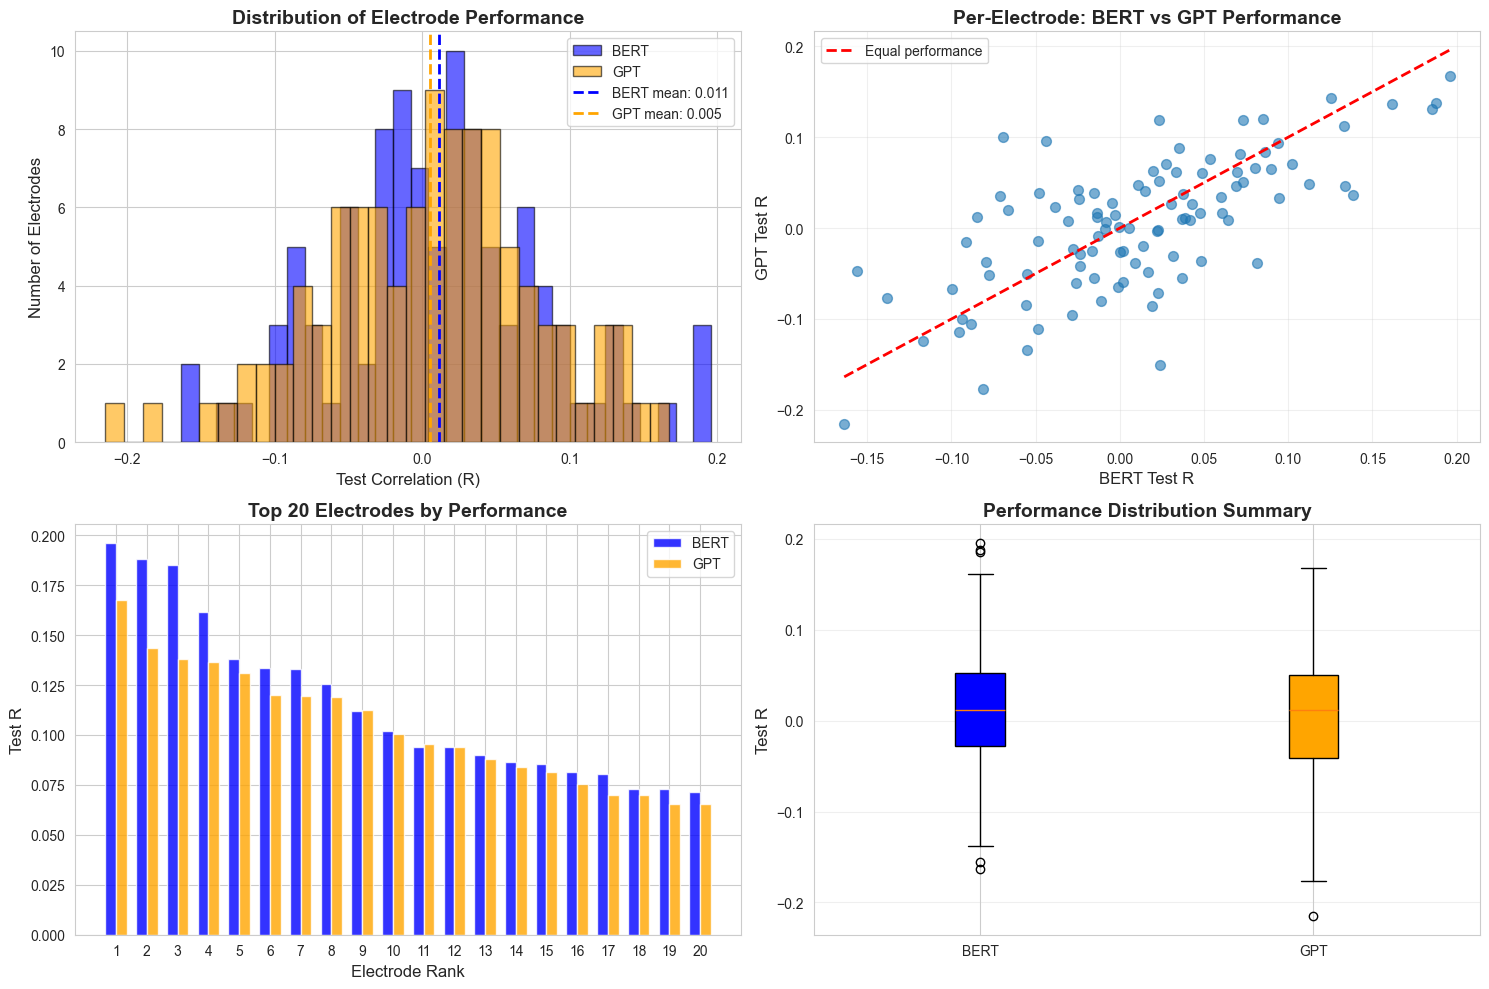


PERFORMANCE SUMMARY

BERT:
  Mean R: 0.011
  Median R: 0.012
  Std R: 0.072
  Max R: 0.196
  Electrodes with R > 0.1: 10

GPT:
  Mean R: 0.005
  Median R: 0.011
  Std R: 0.073
  Max R: 0.168
  Electrodes with R > 0.1: 10


In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Extract results
bert_df = results['bert_results']
gpt_df = results['gpt_results']

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribution of test R values
axes[0, 0].hist(bert_df['test_R'], bins=30, alpha=0.6, label='BERT', color='blue', edgecolor='black')
axes[0, 0].hist(gpt_df['test_R'], bins=30, alpha=0.6, label='GPT', color='orange', edgecolor='black')
axes[0, 0].axvline(bert_df['test_R'].mean(), color='blue', linestyle='--', linewidth=2, label=f'BERT mean: {bert_df["test_R"].mean():.3f}')
axes[0, 0].axvline(gpt_df['test_R'].mean(), color='orange', linestyle='--', linewidth=2, label=f'GPT mean: {gpt_df["test_R"].mean():.3f}')
axes[0, 0].set_xlabel('Test Correlation (R)', fontsize=12)
axes[0, 0].set_ylabel('Number of Electrodes', fontsize=12)
axes[0, 0].set_title('Distribution of Electrode Performance', fontsize=14, fontweight='bold')
axes[0, 0].legend()

# 2. Scatter: BERT vs GPT performance per electrode
axes[0, 1].scatter(bert_df['test_R'], gpt_df['test_R'], alpha=0.6, s=50)
axes[0, 1].plot([bert_df['test_R'].min(), bert_df['test_R'].max()], 
                [bert_df['test_R'].min(), bert_df['test_R'].max()], 
                'r--', linewidth=2, label='Equal performance')
axes[0, 1].set_xlabel('BERT Test R', fontsize=12)
axes[0, 1].set_ylabel('GPT Test R', fontsize=12)
axes[0, 1].set_title('Per-Electrode: BERT vs GPT Performance', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Top 20 electrodes by performance
top_n = 20
bert_top = bert_df.nlargest(top_n, 'test_R')
gpt_top = gpt_df.nlargest(top_n, 'test_R')

x = np.arange(top_n)
width = 0.35
axes[1, 0].bar(x - width/2, bert_top['test_R'].values, width, label='BERT', alpha=0.8, color='blue')
axes[1, 0].bar(x + width/2, gpt_top['test_R'].values, width, label='GPT', alpha=0.8, color='orange')
axes[1, 0].set_xlabel('Electrode Rank', fontsize=12)
axes[1, 0].set_ylabel('Test R', fontsize=12)
axes[1, 0].set_title(f'Top {top_n} Electrodes by Performance', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(range(1, top_n + 1))

# 4. Box plot comparison
data_to_plot = [bert_df['test_R'], gpt_df['test_R']]
bp = axes[1, 1].boxplot(data_to_plot, labels=['BERT', 'GPT'], patch_artist=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][1].set_facecolor('orange')
axes[1, 1].set_ylabel('Test R', fontsize=12)
axes[1, 1].set_title('Performance Distribution Summary', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("PERFORMANCE SUMMARY")
print("="*50)
print(f"\nBERT:")
print(f"  Mean R: {bert_df['test_R'].mean():.3f}")
print(f"  Median R: {bert_df['test_R'].median():.3f}")
print(f"  Std R: {bert_df['test_R'].std():.3f}")
print(f"  Max R: {bert_df['test_R'].max():.3f}")
print(f"  Electrodes with R > 0.1: {(bert_df['test_R'] > 0.1).sum()}")

print(f"\nGPT:")
print(f"  Mean R: {gpt_df['test_R'].mean():.3f}")
print(f"  Median R: {gpt_df['test_R'].median():.3f}")
print(f"  Std R: {gpt_df['test_R'].std():.3f}")
print(f"  Max R: {gpt_df['test_R'].max():.3f}")
print(f"  Electrodes with R > 0.1: {(gpt_df['test_R'] > 0.1).sum()}")

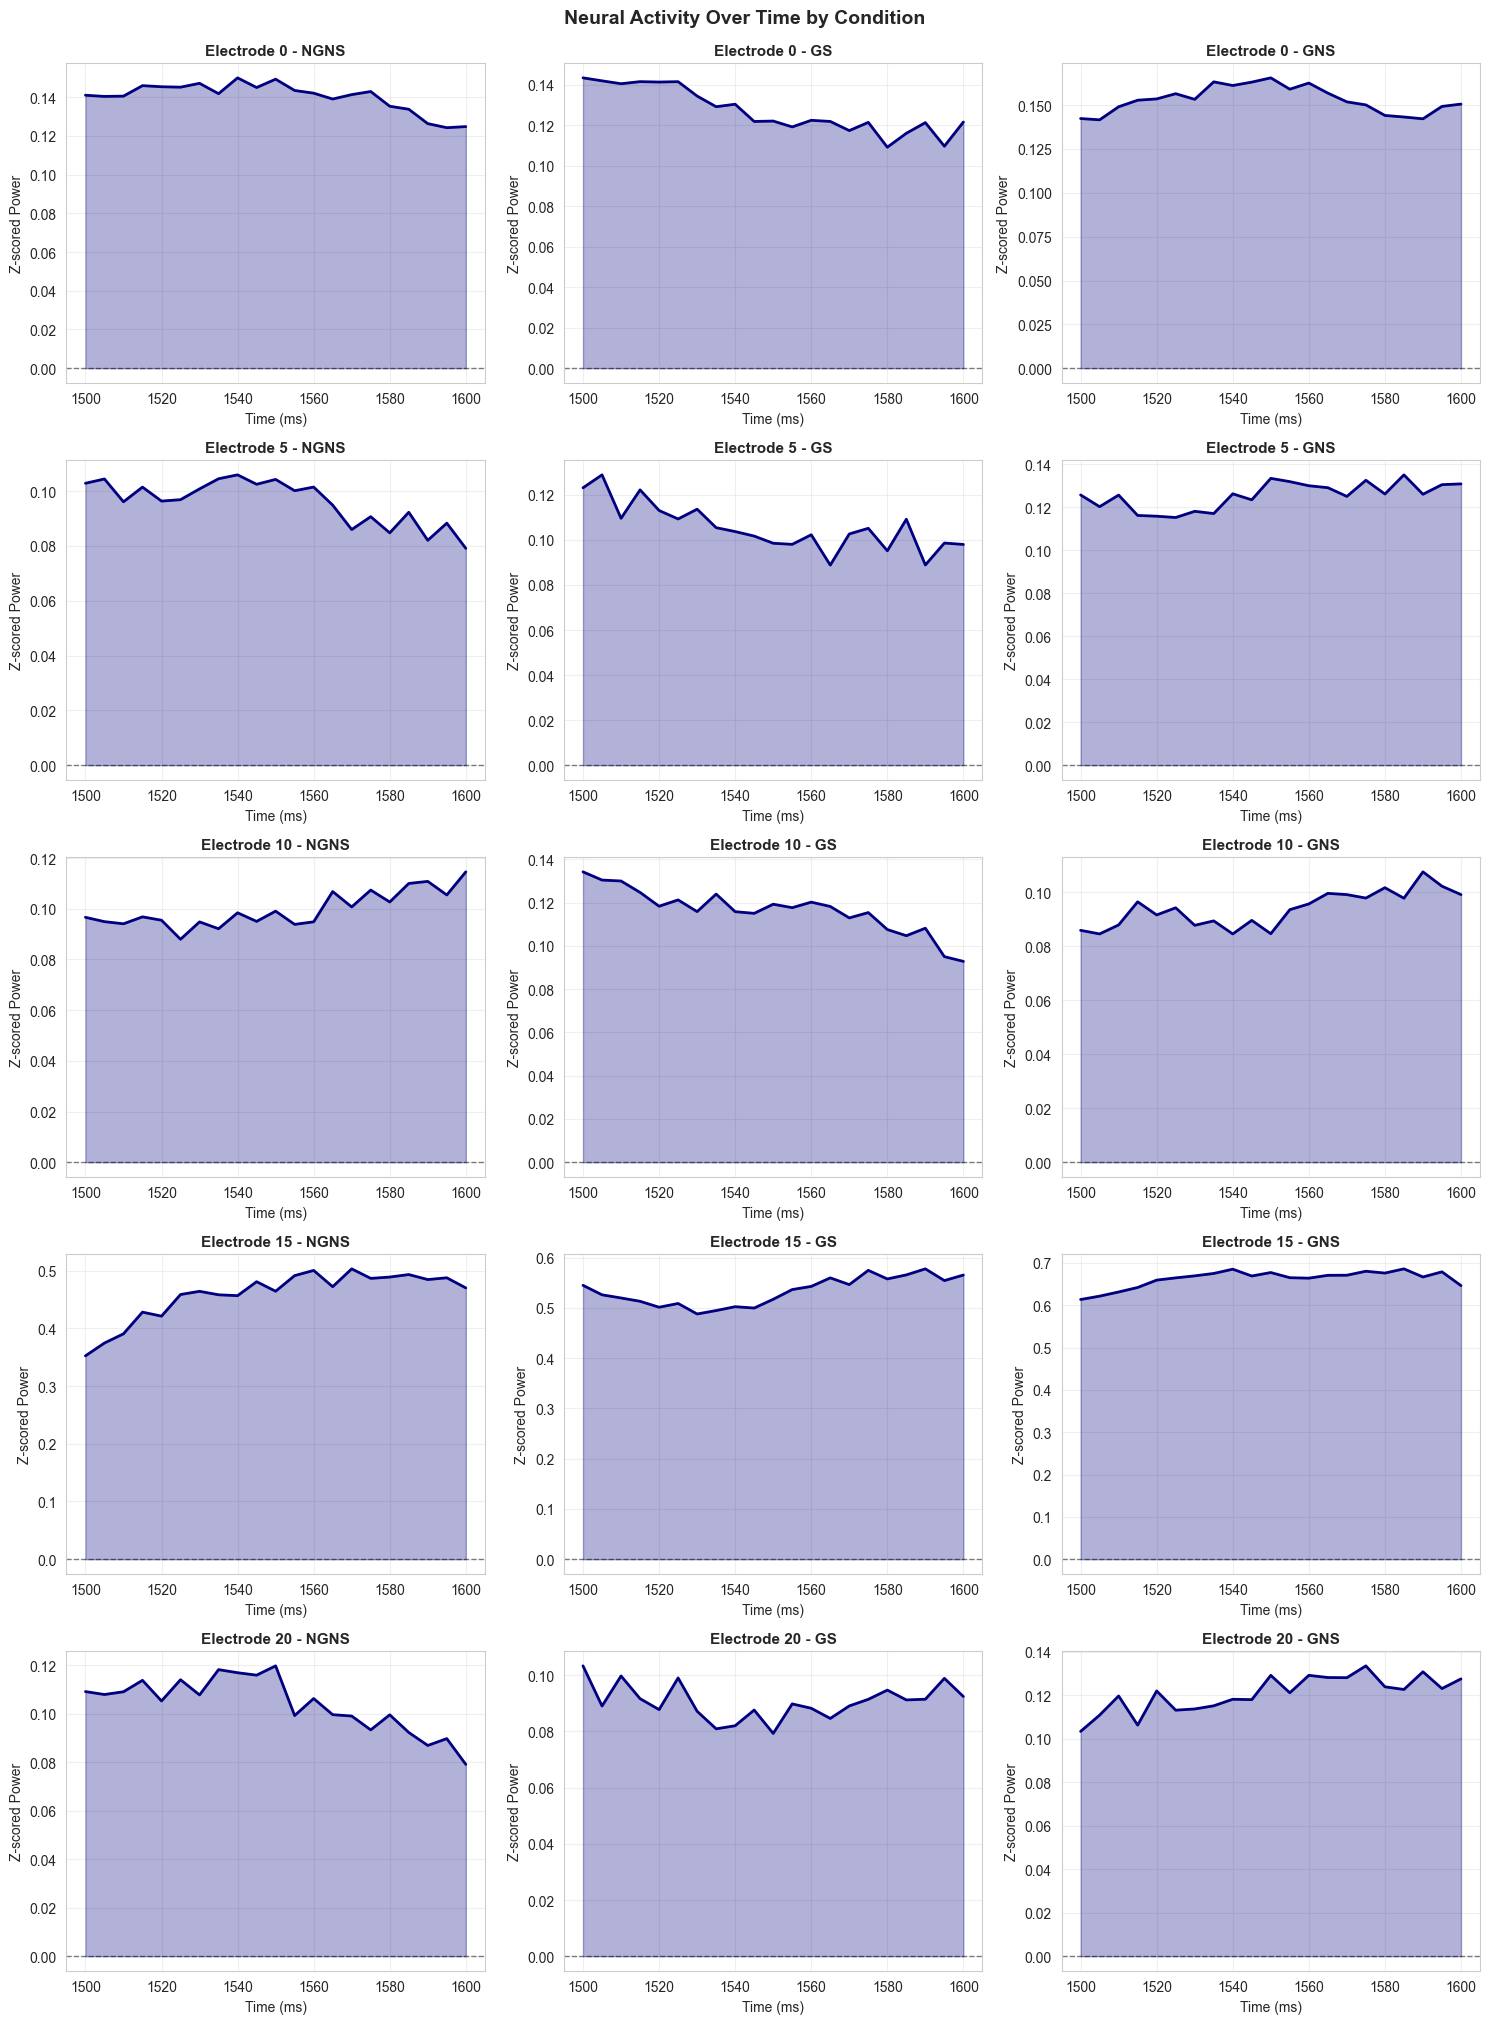

In [61]:
def plot_spectrograms_by_condition(features_df, electrodes_to_plot=[0, 10, 20], 
                                   time_window='consolidation'):
    """
    Plot spectrograms showing power across time for different conditions.
    """
    
    # Filter by time window if specified
    if time_window == 'consolidation':
        time_mask = (features_df['time_start_ms'] >= 1500) & (features_df['time_end_ms'] <= 2500)
    elif time_window == 'full':
        time_mask = np.ones(len(features_df), dtype=bool)
    elif isinstance(time_window, tuple):
        time_mask = (features_df['time_start_ms'] >= time_window[0]) & \
                    (features_df['time_end_ms'] <= time_window[1])
    
    df_window = features_df[time_mask].copy()
    
    # Get unique conditions
    conditions = df_window['sentence_type'].unique()
    n_conditions = len(conditions)
    n_electrodes = len(electrodes_to_plot)
    
    fig, axes = plt.subplots(n_electrodes, n_conditions, 
                             figsize=(5*n_conditions, 4*n_electrodes))
    
    if n_electrodes == 1:
        axes = axes.reshape(1, -1)
    if n_conditions == 1:
        axes = axes.reshape(-1, 1)
    
    for e_idx, electrode in enumerate(electrodes_to_plot):
        for c_idx, condition in enumerate(conditions):
            ax = axes[e_idx, c_idx]
            
            # Filter data for this condition
            condition_data = df_window[df_window['sentence_type'] == condition]
            
            # Get time bins and z-scored power
            time_bins = condition_data['time_start_ms'].unique()
            time_bins = np.sort(time_bins)
            
            # Create matrix: time x trials
            col_name = f'electrode_{electrode}_z_power'
            
            # Group by time window and aggregate
            power_matrix = []
            for t in time_bins:
                power_at_t = condition_data[condition_data['time_start_ms'] == t][col_name].values
                if len(power_at_t) > 0:
                    power_matrix.append(power_at_t.mean())
                else:
                    power_matrix.append(np.nan)
            
            power_matrix = np.array(power_matrix)
            
            # Plot
            ax.plot(time_bins, power_matrix, linewidth=2, color='navy')
            ax.fill_between(time_bins, power_matrix, alpha=0.3, color='navy')
            ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
            ax.set_xlabel('Time (ms)', fontsize=10)
            ax.set_ylabel('Z-scored Power', fontsize=10)
            ax.set_title(f'Electrode {electrode} - {condition}', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Neural Activity Over Time by Condition', 
                 fontsize=14, fontweight='bold', y=1.01)
    plt.show()

# Use it
plot_spectrograms_by_condition(features_df, electrodes_to_plot=[0, 5, 10, 15, 20])

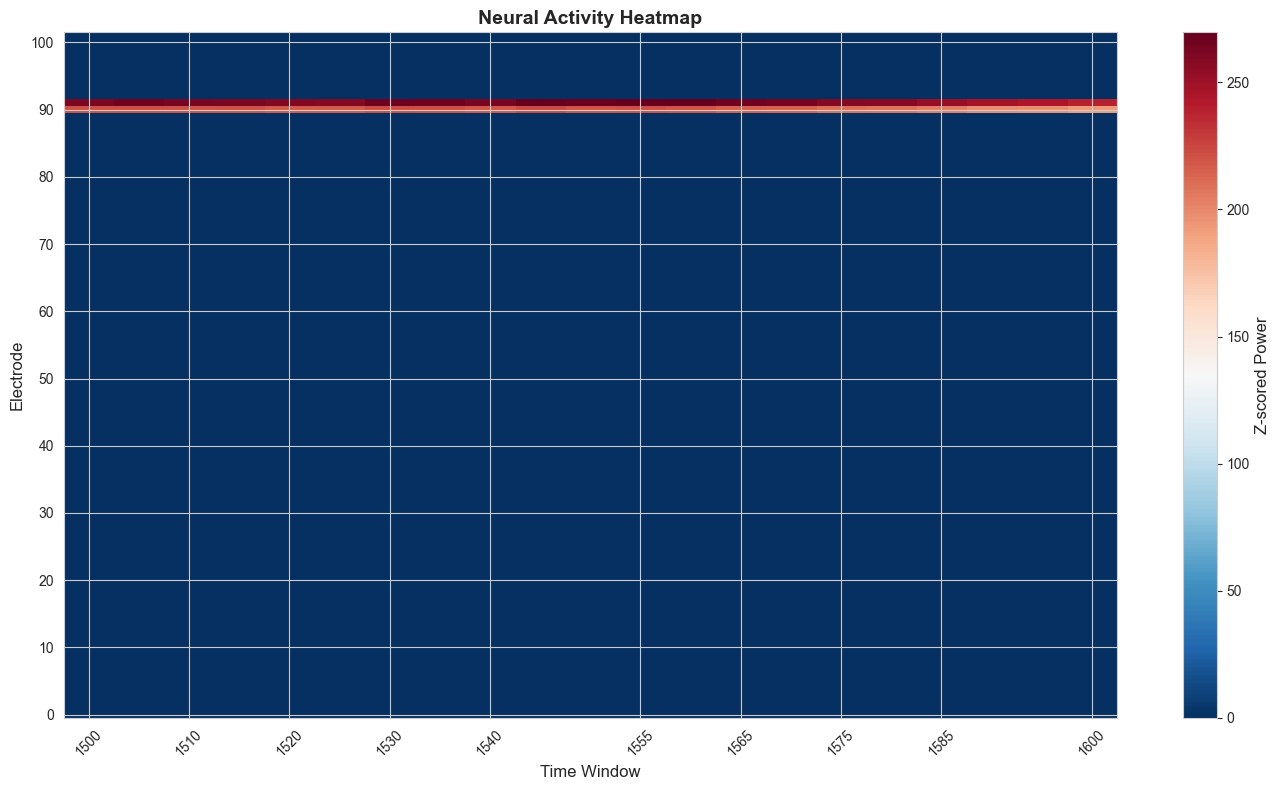

In [62]:
def plot_electrode_heatmap(features_df, condition='all', n_electrodes=50, 
                           time_window='consolidation', use_z_power=True):
    """
    Create a heatmap showing all electrodes over time.
    """
    
    # Filter by time window
    if time_window == 'consolidation':
        time_mask = (features_df['time_start_ms'] >= 1500) & (features_df['time_end_ms'] <= 2500)
    elif time_window == 'full':
        time_mask = np.ones(len(features_df), dtype=bool)
    elif isinstance(time_window, tuple):
        time_mask = (features_df['time_start_ms'] >= time_window[0]) & \
                    (features_df['time_end_ms'] <= time_window[1])
    
    df_window = features_df[time_mask].copy()
    
    # Filter by condition
    if condition != 'all':
        df_window = df_window[df_window['sentence_type'] == condition]
    
    # Get time bins
    time_bins = np.sort(df_window['time_start_ms'].unique())
    
    # Build matrix: time x electrodes
    power_suffix = '_z_power' if use_z_power else '_power'
    power_matrix = np.zeros((len(time_bins), n_electrodes))
    
    for t_idx, t in enumerate(time_bins):
        time_data = df_window[df_window['time_start_ms'] == t]
        for e in range(n_electrodes):
            col = f'electrode_{e}{power_suffix}'
            if col in time_data.columns:
                power_matrix[t_idx, e] = time_data[col].mean()
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 8))
    
    im = ax.imshow(power_matrix.T, aspect='auto', cmap='RdBu_r', 
                   interpolation='nearest', origin='lower')
    
    # Set labels
    ax.set_xlabel('Time Window', fontsize=12)
    ax.set_ylabel('Electrode', fontsize=12)
    
    # Set x-axis ticks to show actual time
    n_ticks = min(10, len(time_bins))
    tick_indices = np.linspace(0, len(time_bins)-1, n_ticks, dtype=int)
    ax.set_xticks(tick_indices)
    ax.set_xticklabels([f'{int(time_bins[i])}' for i in tick_indices], rotation=45)
    
    # Set y-axis
    y_ticks = np.arange(0, n_electrodes, max(1, n_electrodes//10))
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_ticks)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Z-scored Power' if use_z_power else 'Power', fontsize=12)
    
    title = f'Neural Activity Heatmap'
    if condition != 'all':
        title += f' - {condition}'
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Use it
plot_electrode_heatmap(features_df, condition='all', n_electrodes=102, 
                       time_window='consolidation')

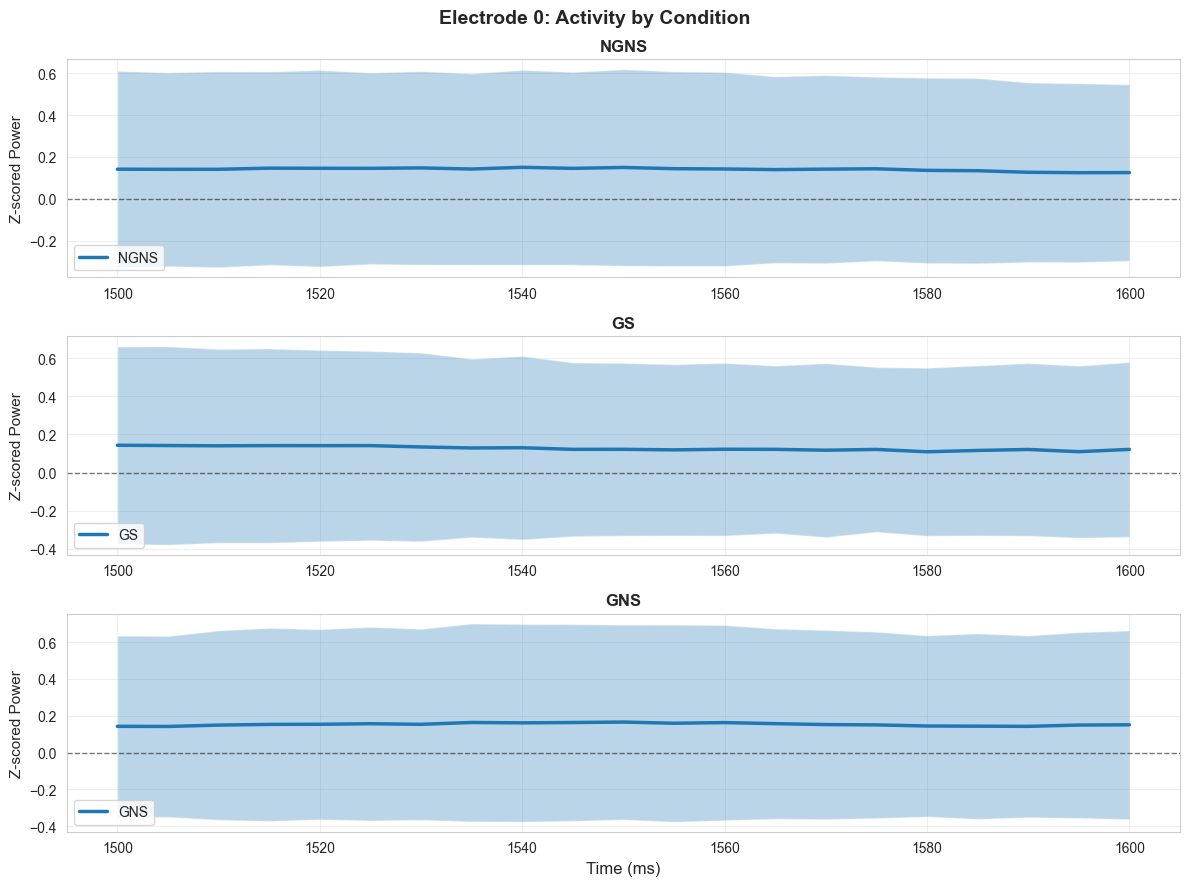

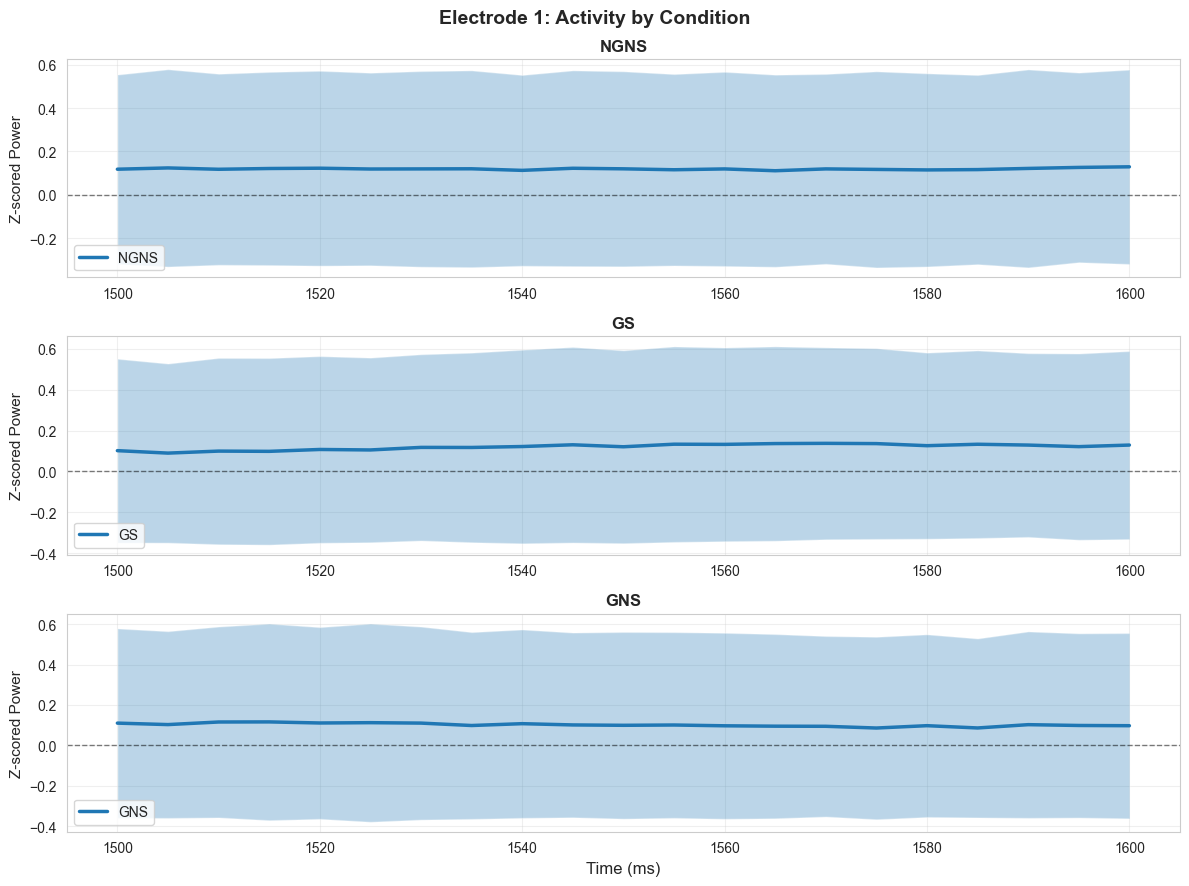

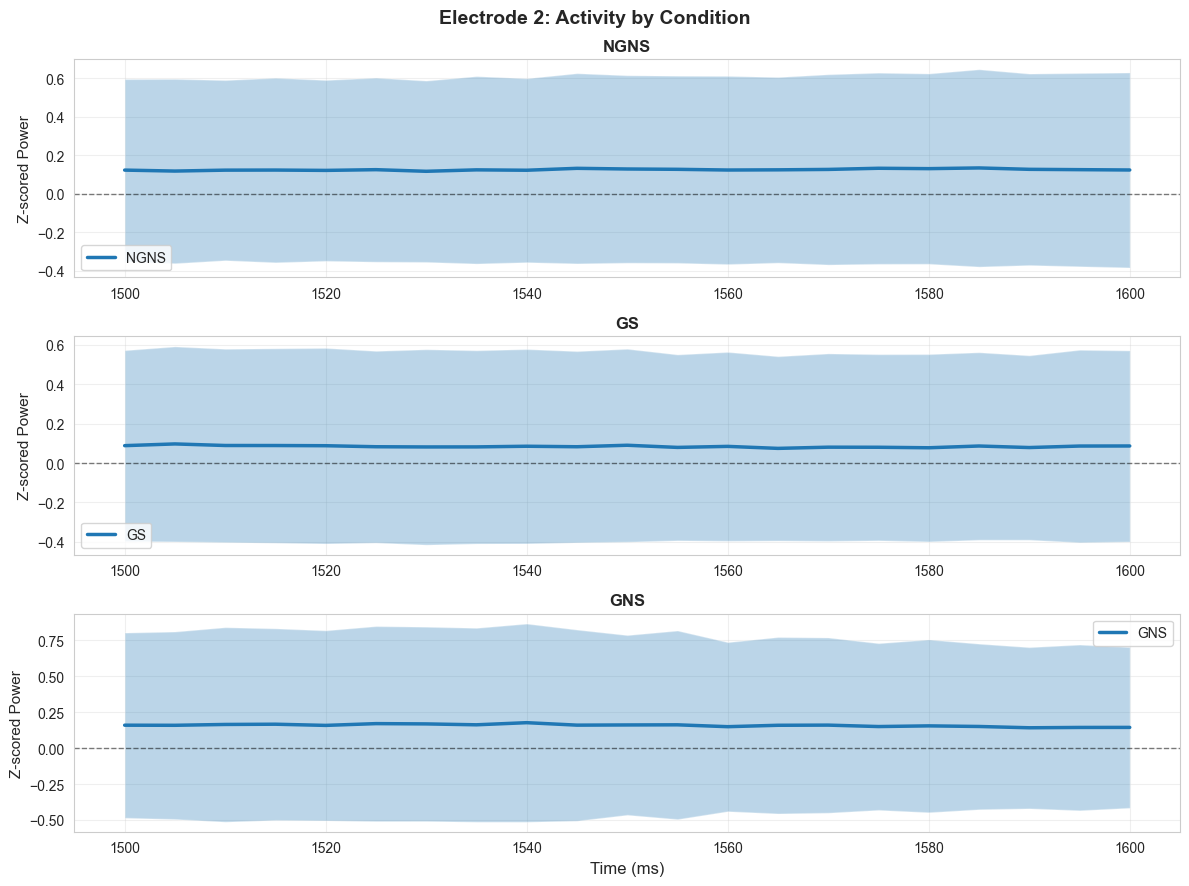

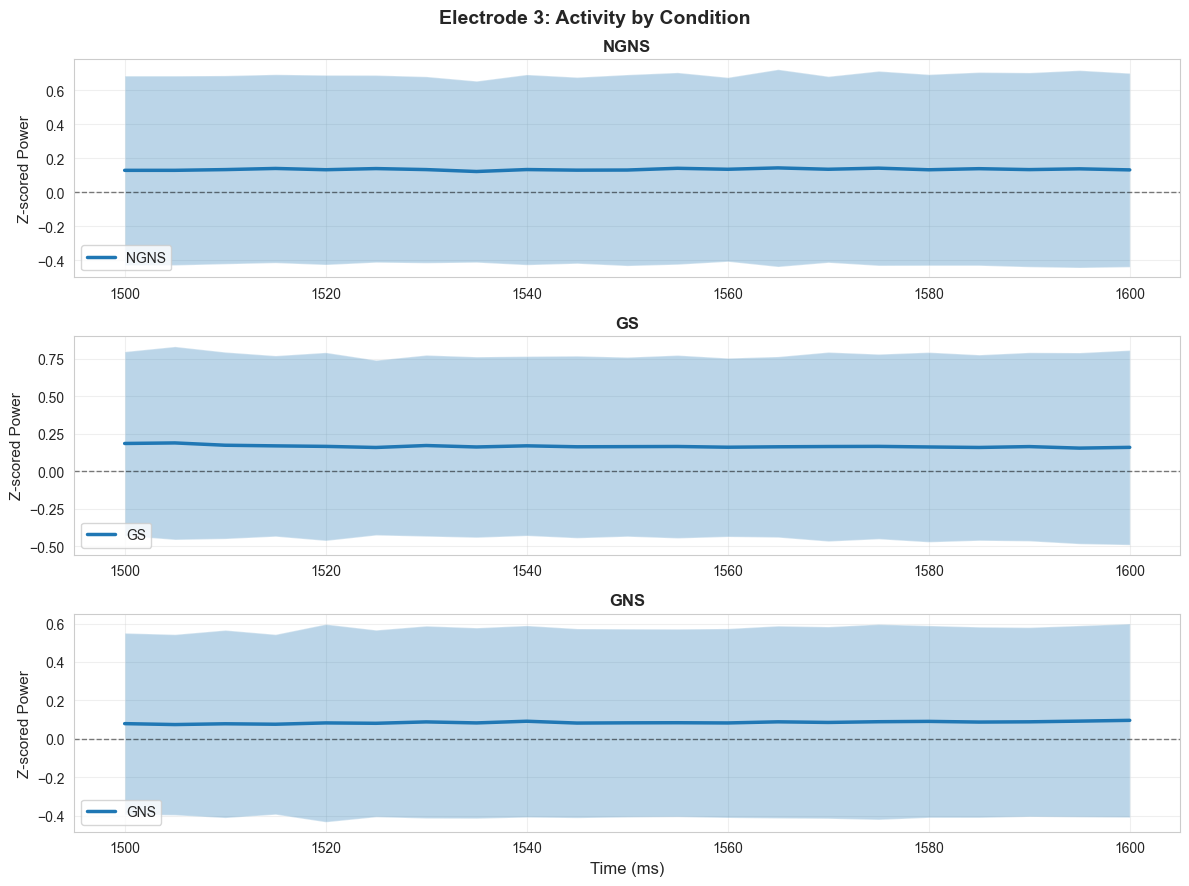

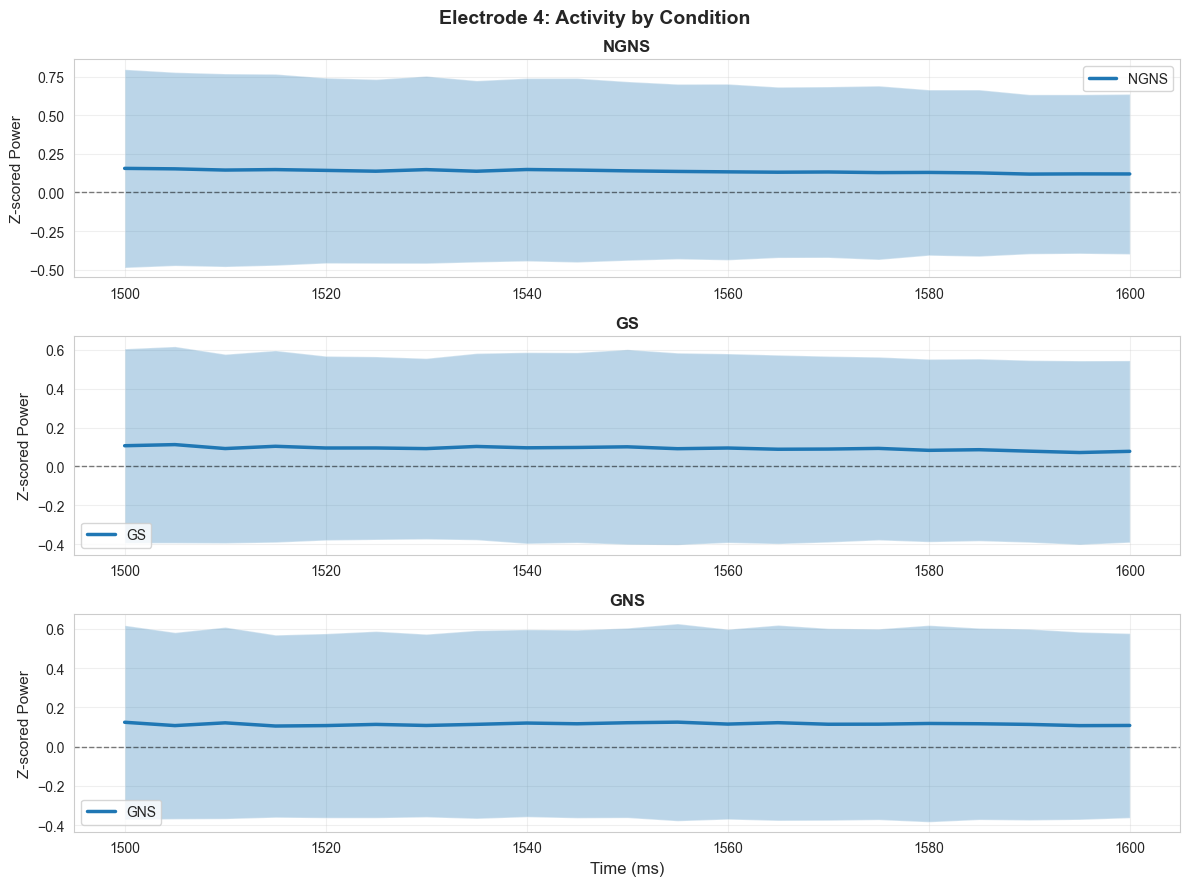

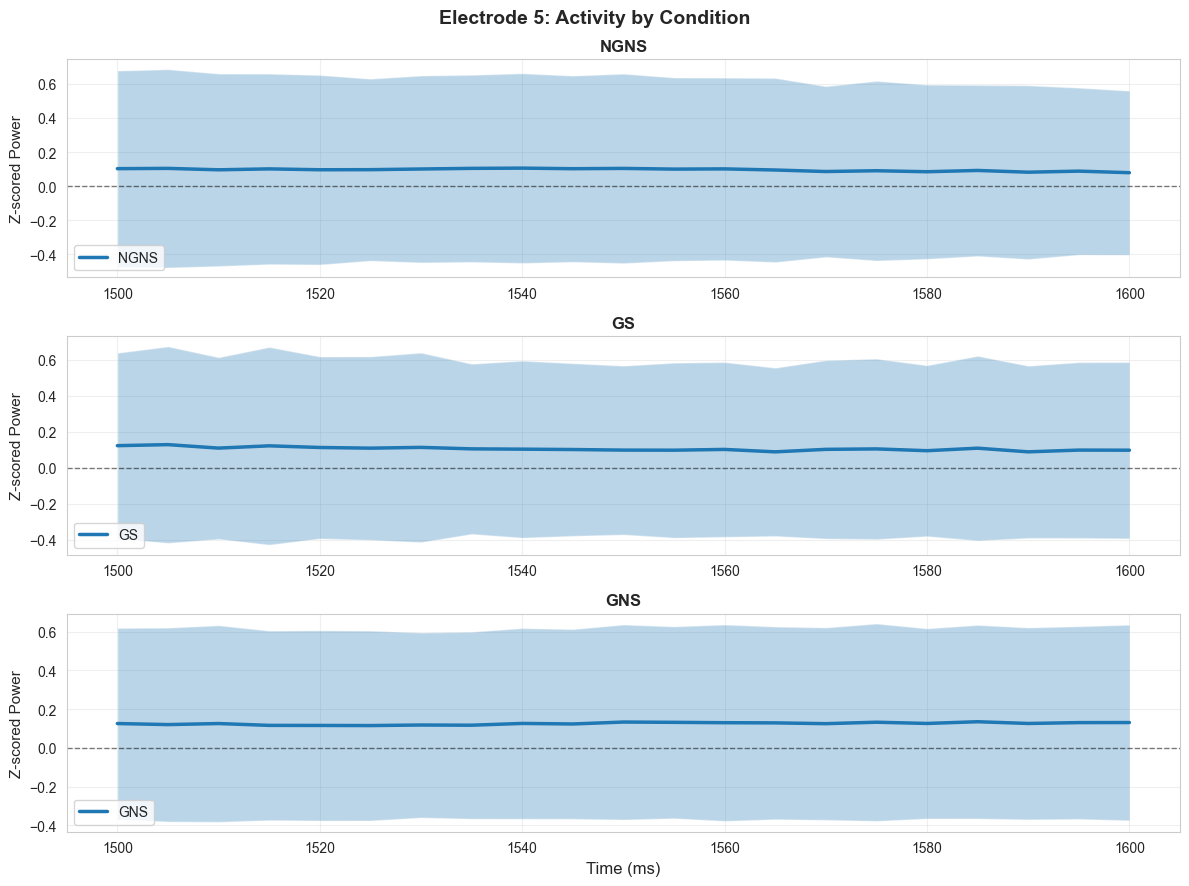

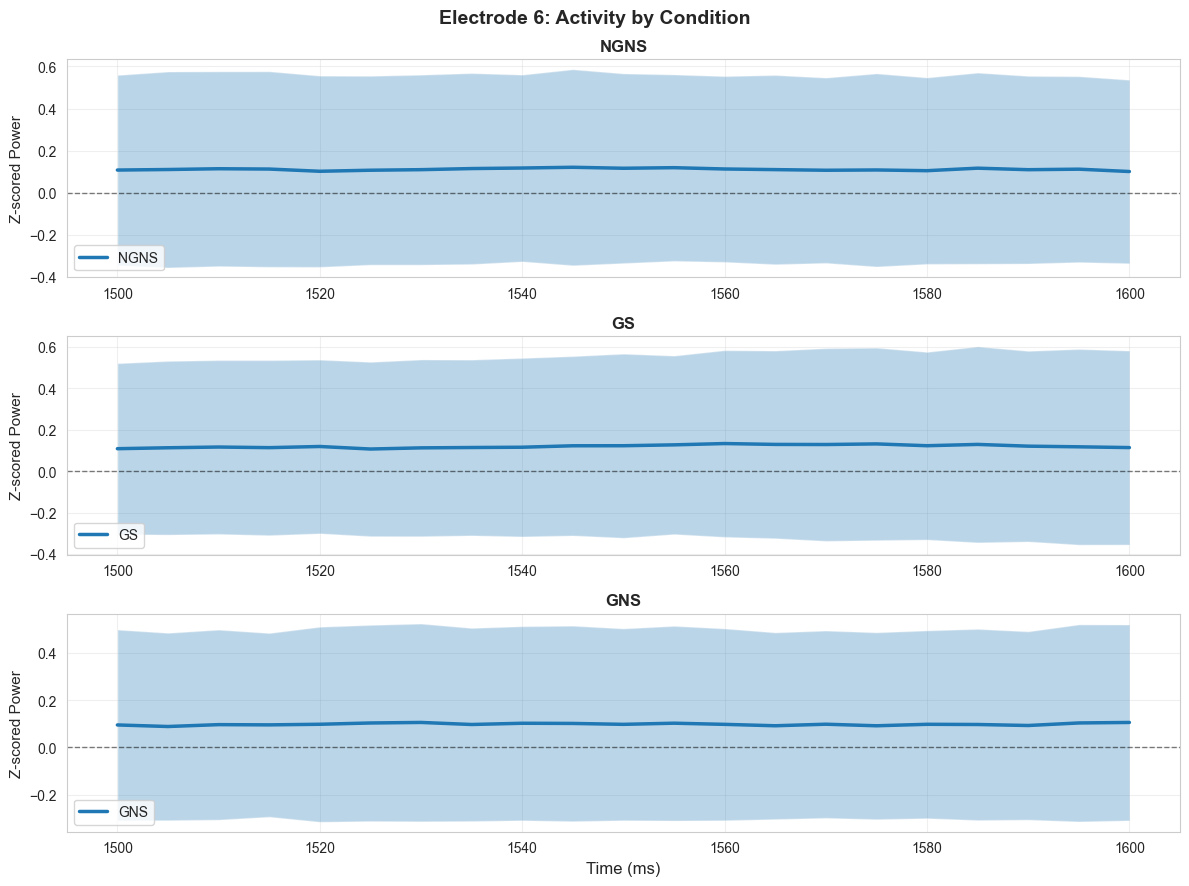

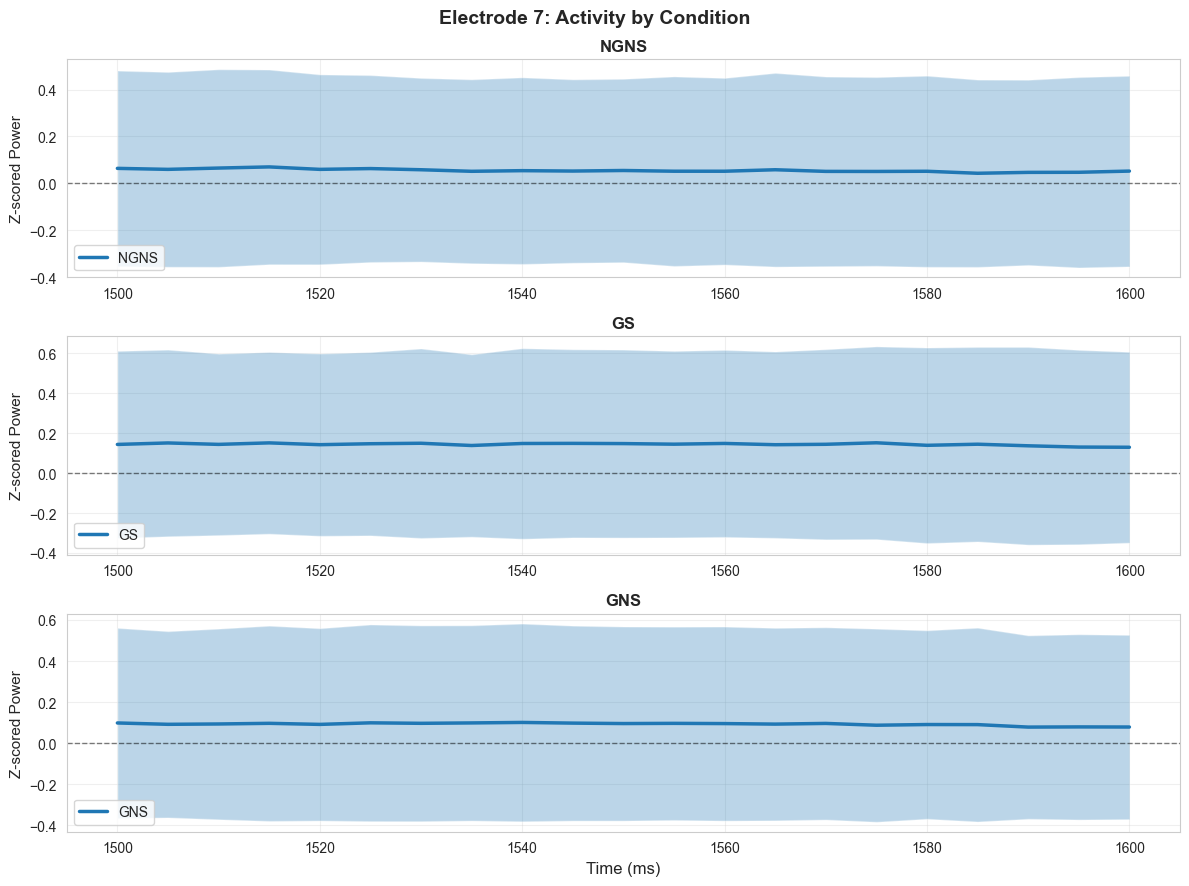

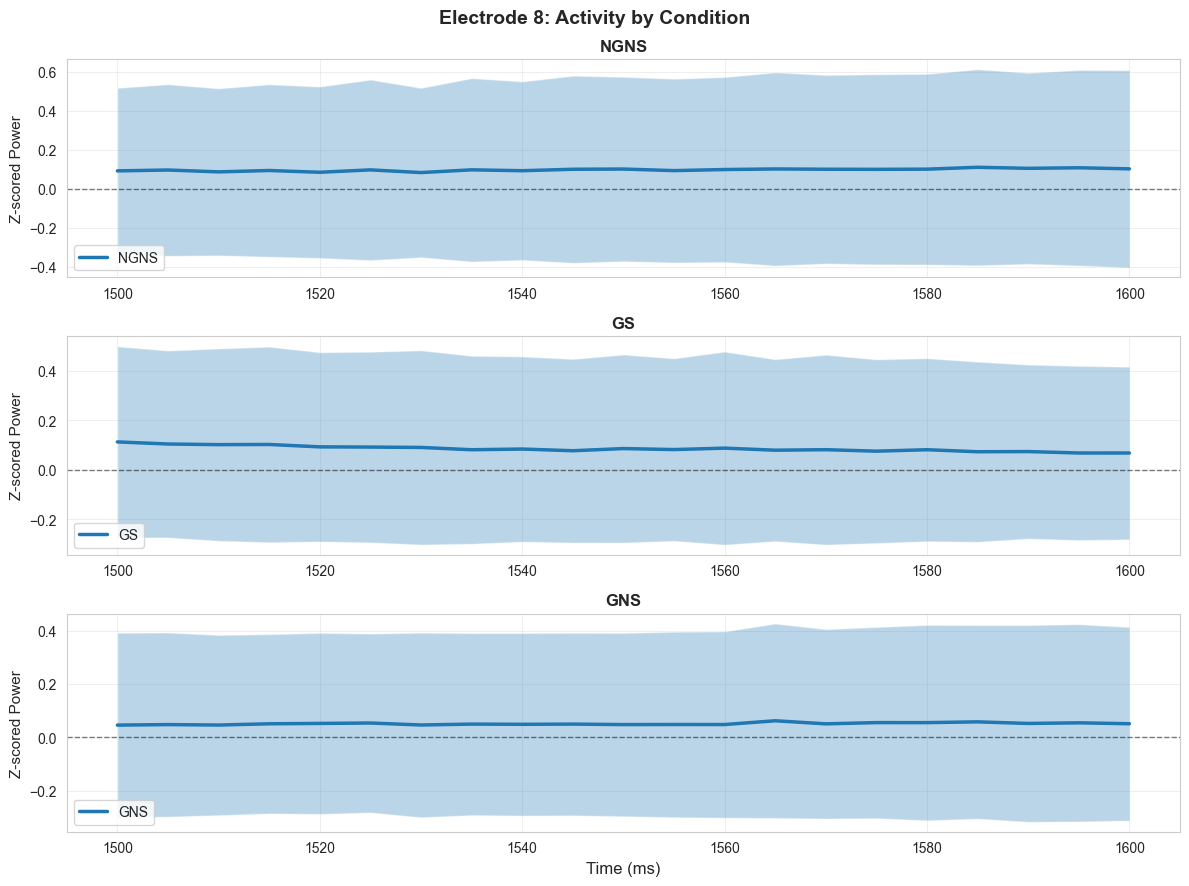

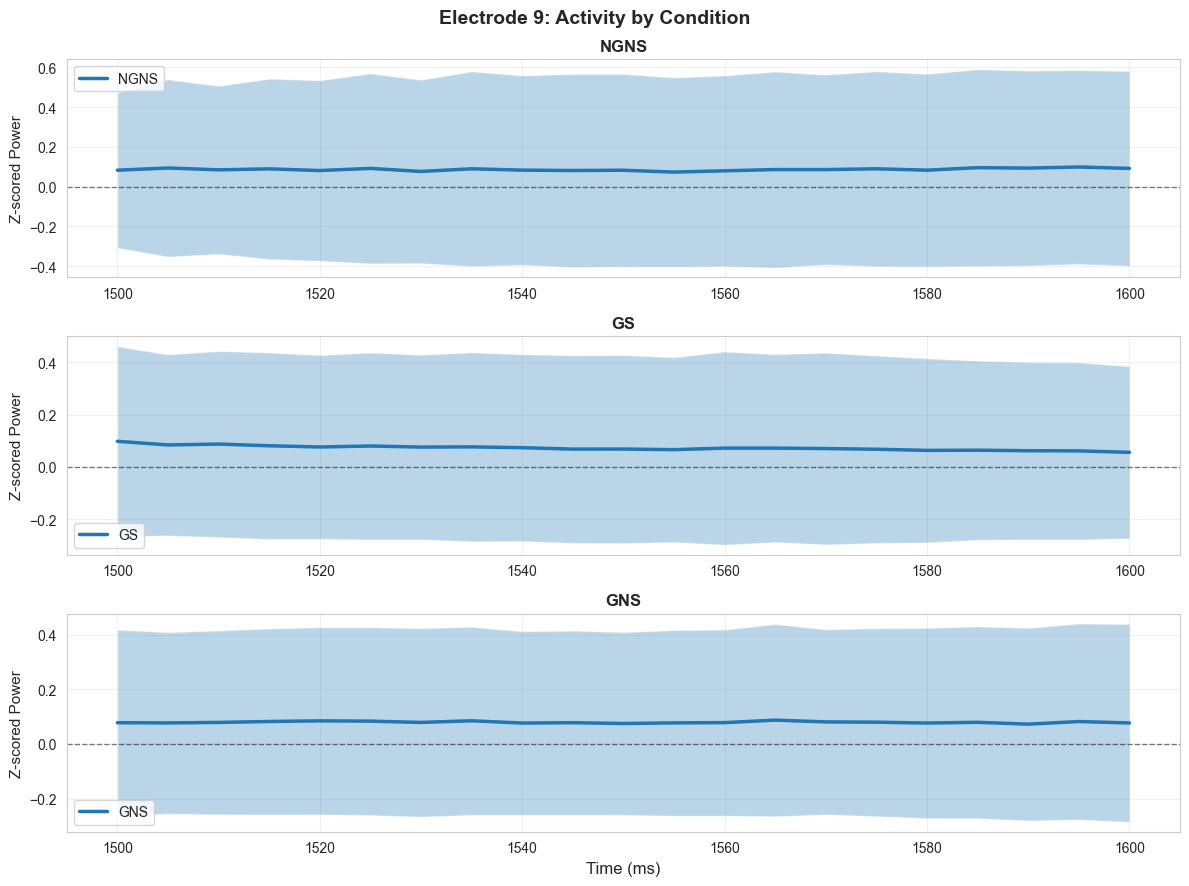

In [64]:
def plot_condition_comparison_spectrograms(features_df, electrode=0, 
                                          time_window='consolidation'):
    """
    Compare spectrograms across conditions for a single electrode.
    """
    
    # Filter by time window
    if time_window == 'consolidation':
        time_mask = (features_df['time_start_ms'] >= 1500) & (features_df['time_end_ms'] <= 2500)
    elif time_window == 'full':
        time_mask = np.ones(len(features_df), dtype=bool)
    elif isinstance(time_window, tuple):
        time_mask = (features_df['time_start_ms'] >= time_window[0]) & \
                    (features_df['time_end_ms'] <= time_window[1])
    
    df_window = features_df[time_mask].copy()
    
    conditions = df_window['sentence_type'].unique()
    n_conditions = len(conditions)
    
    fig, axes = plt.subplots(n_conditions, 1, figsize=(12, 3*n_conditions))
    if n_conditions == 1:
        axes = [axes]
    
    time_bins = np.sort(df_window['time_start_ms'].unique())
    col_name = f'electrode_{electrode}_z_power'
    
    for idx, condition in enumerate(conditions):
        condition_data = df_window[df_window['sentence_type'] == condition]
        
        # Get power across time (average across trials)
        power_over_time = []
        power_std = []
        
        for t in time_bins:
            powers = condition_data[condition_data['time_start_ms'] == t][col_name].values
            if len(powers) > 0:
                power_over_time.append(powers.mean())
                power_std.append(powers.std())
            else:
                power_over_time.append(np.nan)
                power_std.append(np.nan)
        
        power_over_time = np.array(power_over_time)
        power_std = np.array(power_std)
        
        # Plot with error bands
        axes[idx].plot(time_bins, power_over_time, linewidth=2.5, label=condition)
        axes[idx].fill_between(time_bins, 
                               power_over_time - power_std,
                               power_over_time + power_std,
                               alpha=0.3)
        axes[idx].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        axes[idx].set_ylabel('Z-scored Power', fontsize=11)
        axes[idx].set_title(f'{condition}', fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend()
    
    axes[-1].set_xlabel('Time (ms)', fontsize=12)
    plt.suptitle(f'Electrode {electrode}: Activity by Condition', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Use it
for i in range(10):
    plot_condition_comparison_spectrograms(features_df, electrode=i, 
                                        time_window='consolidation')

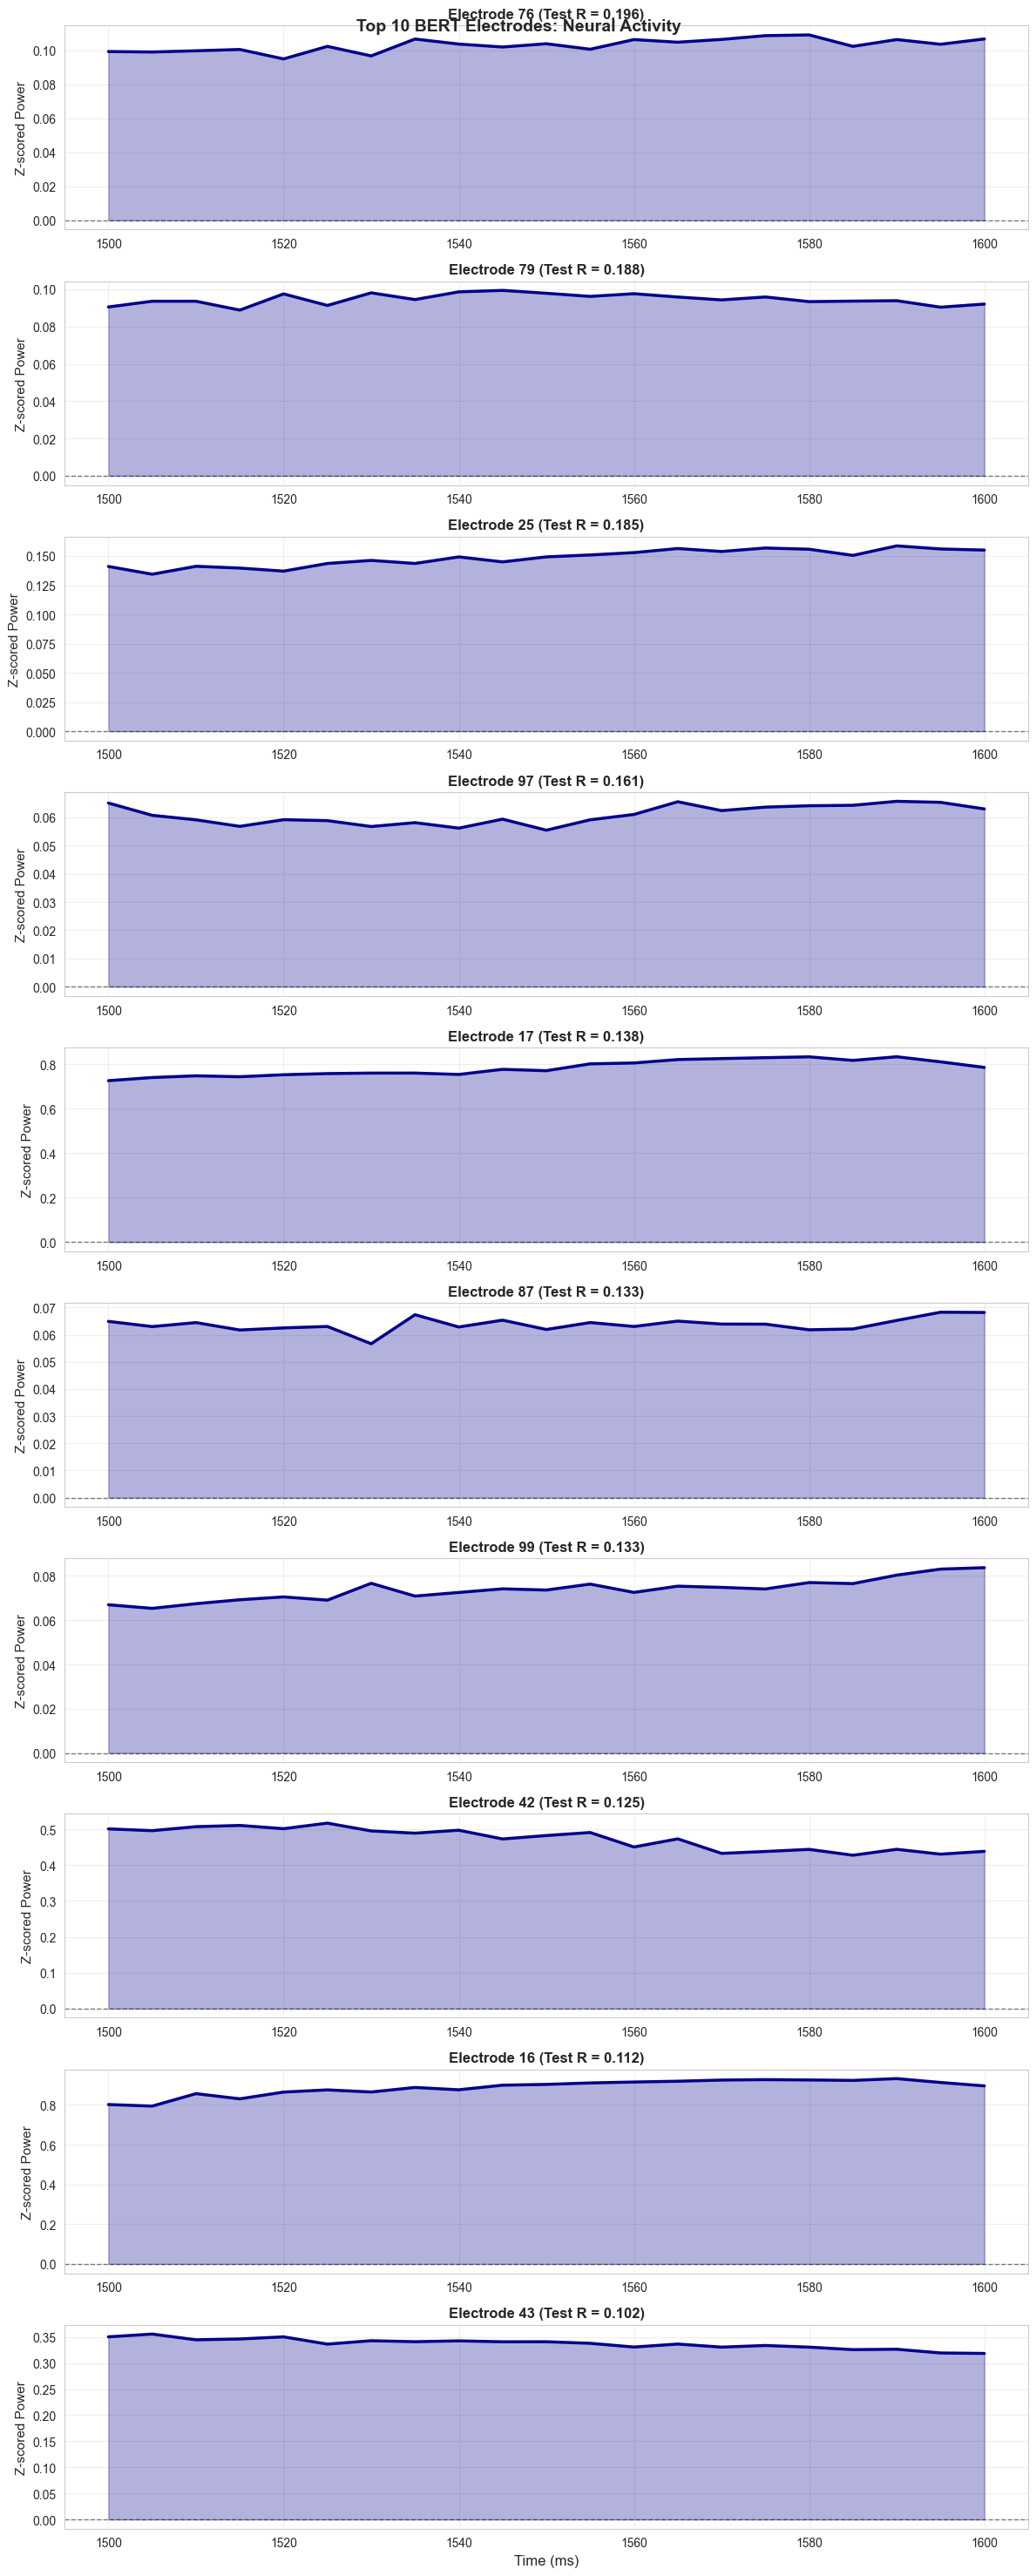

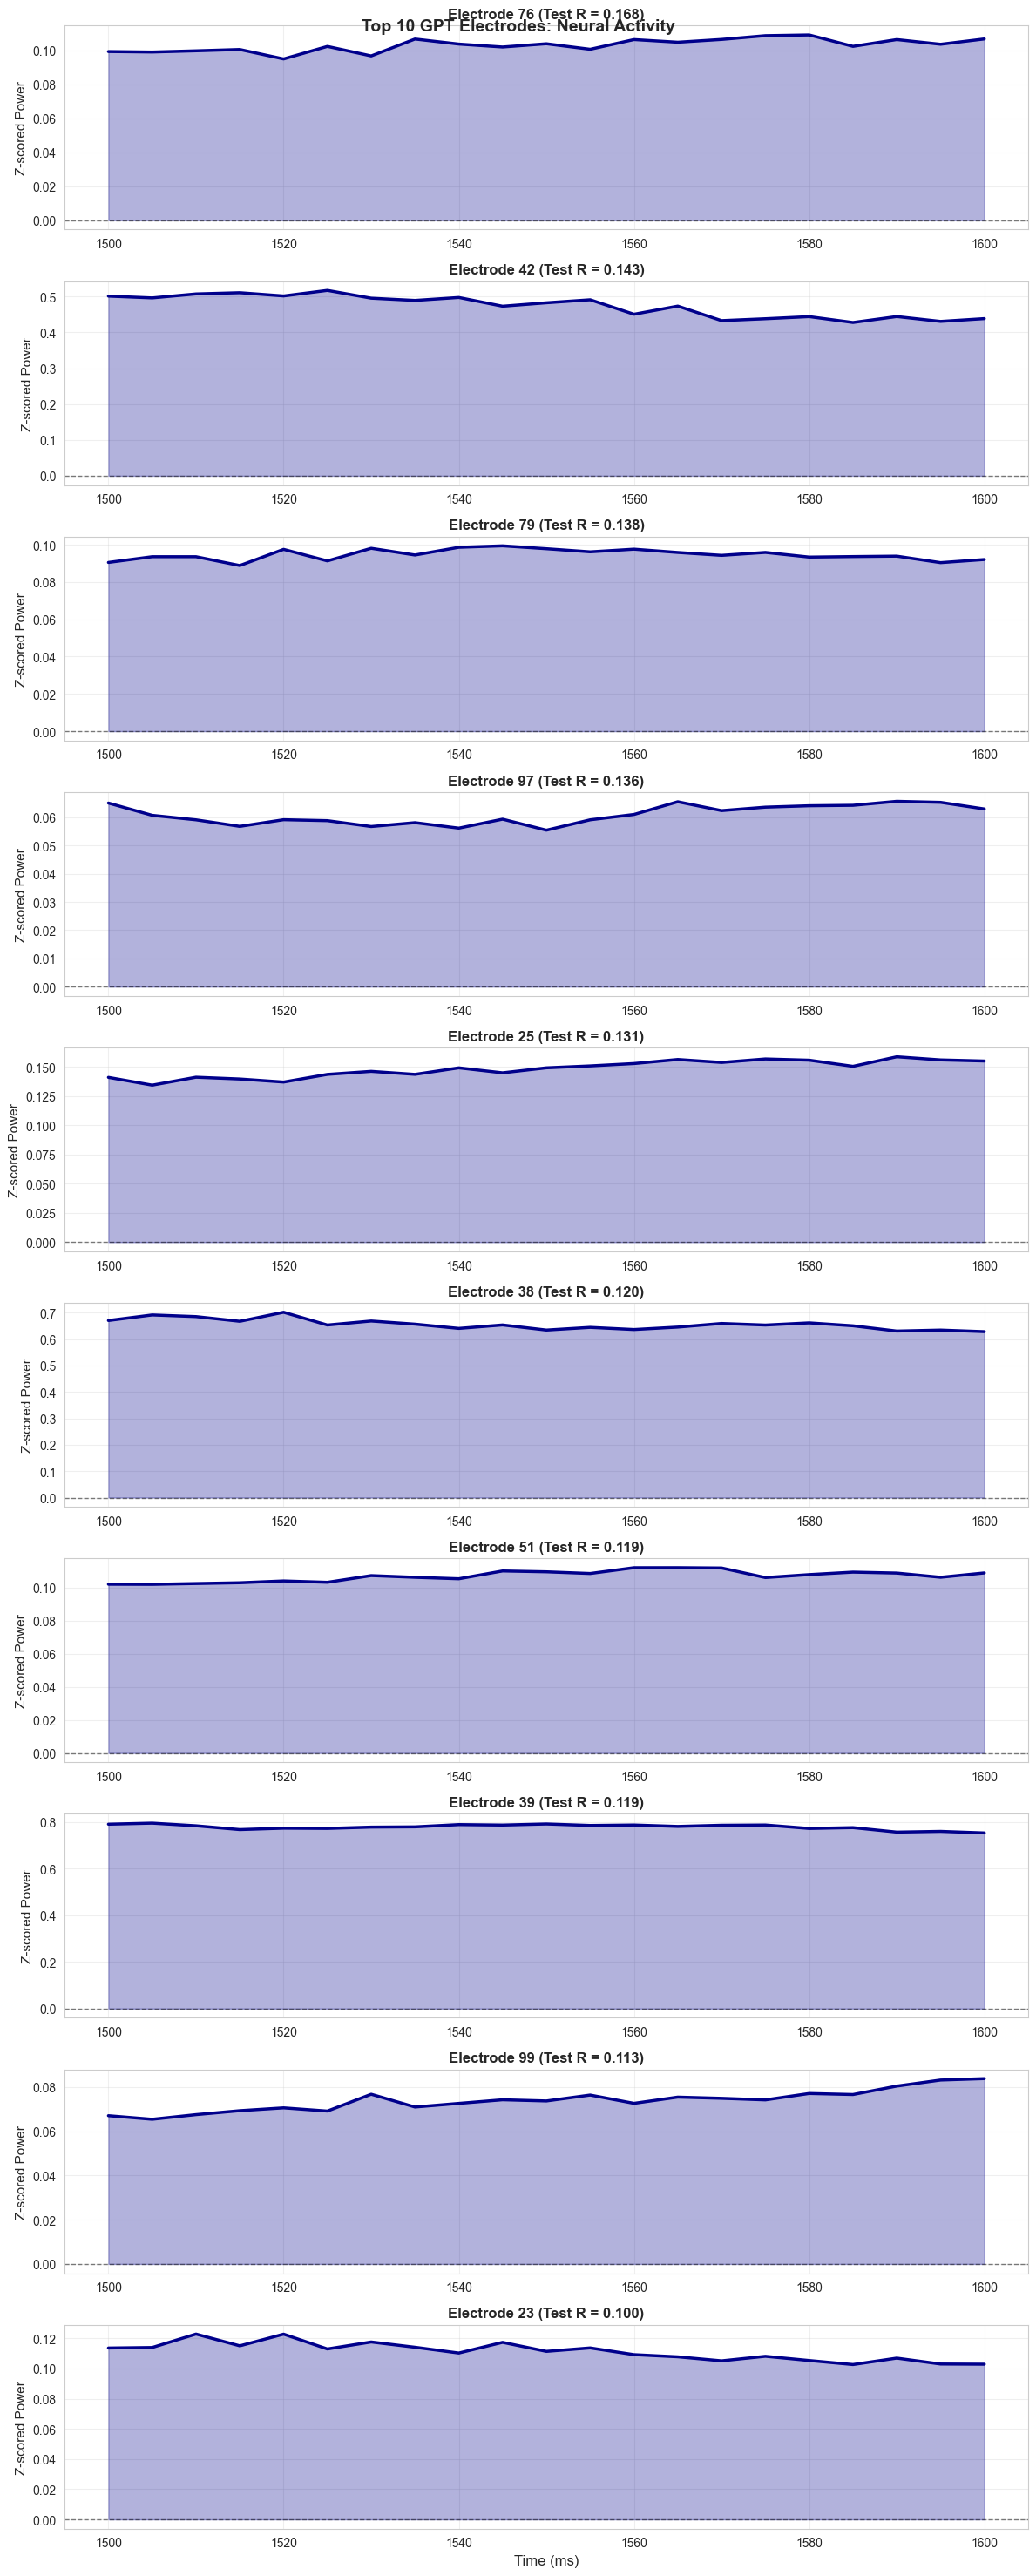

In [66]:
def plot_top_electrodes_spectrograms(results, features_df, model_name='BERT', 
                                     top_n=5, time_window='consolidation'):
    """
    Plot spectrograms for the best performing electrodes.
    """
    
    # Get results for the specified model
    if model_name == 'BERT':
        results_df = results['bert_results']
    else:
        results_df = results['gpt_results']
    
    # Get top electrodes
    top_electrodes = results_df.nlargest(top_n, 'test_R')
    electrode_indices = [int(e.split('_')[1]) for e in top_electrodes['electrode']]
    
    # Filter by time window
    if time_window == 'consolidation':
        time_mask = (features_df['time_start_ms'] >= 1500) & (features_df['time_end_ms'] <= 2500)
    elif time_window == 'full':
        time_mask = np.ones(len(features_df), dtype=bool)
    elif isinstance(time_window, tuple):
        time_mask = (features_df['time_start_ms'] >= time_window[0]) & \
                    (features_df['time_end_ms'] <= time_window[1])
    
    df_window = features_df[time_mask].copy()
    time_bins = np.sort(df_window['time_start_ms'].unique())
    
    fig, axes = plt.subplots(top_n, 1, figsize=(12, 3*top_n))
    if top_n == 1:
        axes = [axes]
    
    for idx, (e, test_r) in enumerate(zip(electrode_indices, top_electrodes['test_R'])):
        col_name = f'electrode_{e}_z_power'
        
        # Get average power over time
        power_over_time = []
        for t in time_bins:
            power = df_window[df_window['time_start_ms'] == t][col_name].mean()
            power_over_time.append(power)
        
        axes[idx].plot(time_bins, power_over_time, linewidth=2.5, color='darkblue')
        axes[idx].fill_between(time_bins, power_over_time, alpha=0.3, color='darkblue')
        axes[idx].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        axes[idx].set_ylabel('Z-scored Power', fontsize=11)
        axes[idx].set_title(f'Electrode {e} (Test R = {test_r:.3f})', 
                           fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time (ms)', fontsize=12)
    plt.suptitle(f'Top {top_n} {model_name} Electrodes: Neural Activity', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Use it
plot_top_electrodes_spectrograms(results, features_df, model_name='BERT', 
                                 top_n=10, time_window='consolidation')

plot_top_electrodes_spectrograms(results, features_df, model_name='GPT', 
                                 top_n=10, time_window='consolidation')

In [ ]:
def comprehensive_spectrogram_analysis(results, features_df, time_window='consolidation'):
    """
    Complete spectrogram analysis in one function.
    """
    
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # 1. Heatmap for all electrodes
    ax1 = fig.add_subplot(gs[0, :])
    # ... (use heatmap code from above)
    
    # 2. Top BERT electrode
    ax2 = fig.add_subplot(gs[1, 0])
    # ... (spectrogram for top BERT)
    
    # 3. Top GPT electrode  
    ax3 = fig.add_subplot(gs[1, 1])
    # ... (spectrogram for top GPT)
    
    # 4. Average across all electrodes by condition
    ax4 = fig.add_subplot(gs[2, :])
    # ... (condition comparison)
    
    plt.show()

# Use all visualizations
plot_spectrograms_by_condition(features_df, electrodes_to_plot=[0, 20, 40, 60, 80, 100])
plot_electrode_heatmap(features_df, n_electrodes=102)
plot_top_electrodes_spectrograms(results, features_df, model_name='BERT', top_n=10)
plot_top_electrodes_spectrograms(results, features_df, model_name='GPT', top_n=10)

In [40]:
#sentence_input = sentence_pool() 

In [3]:
sub_8 = Subject("S8", 1, DIRECTORYS[2])
sub_8.load_behav_mat()
sub_8.convert_behav_mats()
sub_8.load_neuro_mat()
sub_8.convert_neuro_mat()

In [4]:
# NEW: Use filtering without trial averaging
#sub_8.pre_process_gamma(do_trial_averaging=False)  # Keep full data <- Find ways to optimize this more 
sub_8.record_filter = np.load('sub_8_record_filter.npy')



In [39]:
#Make sure to pickle save this data
#np.save('sub_8_record_filter.npy', sub_8.record_filter) #Save me some time 

In [5]:
# Extract features from consolidation window
trial_df = align_triggers_from_system_time(sub_8) 

# Remove any trials with NaN values
trial_df = trial_df.dropna()

System time range: 893.27s to 10498.37s
Converted to samples: 893269 to 10498366
⚠️ 1101 events fall outside recording bounds and will be excluded
Retained 7218 valid triggers


In [41]:
trial_df

,Type,number,trig_sent,system_timePreOnset,system_timePostTrigger,sentence,block_num,stim_num,response,Var1,Var2,event_samples
0,START,8,1,893.269801,894.008876,"{'sen_field': [[b'', b'MCOS', b'containers.Map...",-1,-1,-1,989924,8,893269
1,FIXATION1_VIS,1,1,894.028258,894.057878,"{'sen_field': {'w1': 'the', 'w2': 'wrote', 'w3...",1,1,-1,990675,1,894028
2,WORD1_VIS,1,1,894.631268,894.656295,"{'sen_field': {'w1': 'the', 'w2': 'wrote', 'w3...",1,1,-1,991274,1,894631
3,WORD2_VIS,1,1,895.508225,895.539099,"{'sen_field': {'w1': 'the', 'w2': 'wrote', 'w3...",1,1,-1,992157,1,895508
4,WORD3_VIS,1,1,896.389503,896.422508,"{'sen_field': {'w1': 'the', 'w2': 'wrote', 'w3...",1,1,-1,993041,1,896389
...,...,...,...,...,...,...,...,...,...,...,...,...
7213,SW_HASH,1,1,8997.248617,8997.286527,"{'sen_field': {'word': '########', 'type': 'CC...",7,118,"{'trial_success': -4, 'buttonpressed': -1, 're...",9093946,1,8997248
7214,SW_FIXN,1,1,8998.121786,8998.152454,"{'sen_field': {'word': 'rode', 'type': 'VERB'}}",7,119,-1,9094812,1,8998121
7215,SW_WORD,1,1,8998.731588,8998.768941,"{'sen_field': {'word': 'rode', 'type': 'VERB'}}",7,119,-1,9095429,1,8998731
7216,SW_FIXN,1,1,8999.041304,8999.069095,"{'sen_field': {'word': '########', 'type': 'CC...",7,120,-1,9095729,1,8999041


In [42]:
sub_8.record_filter

array([[ 1.26945749e-01,  6.28628349e-03, -3.07435729e-02, ...,
        -8.45242664e-02, -5.93847670e-02, -1.06997013e-01],
       [ 2.03556016e-01,  5.35822988e-01,  7.58086801e-01, ...,
         5.37828445e-01,  4.35184240e-01,  2.82691270e-01],
       [-1.48281261e-01,  1.25369155e+00,  2.41450596e+00, ...,
         8.76997560e-02,  2.58143097e-01,  5.83927929e-01],
       ...,
       [ 1.02958775e+01,  3.79513641e+02,  6.73508362e+02, ...,
         5.18383942e+01,  4.75696640e+01,  3.73982391e+01],
       [-4.42052193e+01,  7.77098846e+01,  1.69347717e+02, ...,
        -2.53750961e+02, -6.80160370e+01,  7.66056595e+01],
       [ 5.67746782e+00, -1.77522064e+02, -3.16626221e+02, ...,
        -8.24961166e+01, -1.25491440e+02, -1.23587975e+02]],
      shape=(102, 9000001), dtype=float32)

In [43]:
"""
Note: Might not need this cell
Extract sentences from trigger data
word_keys = {
    'w1': ['w1', 'word1', 'W1', 'Word1'],
    'w2': ['w2', 'word2', 'W2', 'Word2'],
    'w3': ['w3', 'word3', 'W3', 'Word3'],
    'w4': ['w4', 'word4', 'W4', 'Word4']
}
def extract_sentence_from_dict(sen_dict):
    if not isinstance(sen_dict, dict):
        return ""
    
    words = []
    for key in word_keys:
        for item in word_keys[key]: #Go through all the words
            if key in sen_dict and sen_dict[key]:
                words.append(str(sen_dict[key]))
                break #no need to find the other instances if we already found one of the permutations
    
    return ' '.join(words)
# Apply to trigger frame
sentences = []
for idx in range(len(trial_df['sentence'])):
    if idx < len(sub_8.trigger_frame):
        sen_dict = sub_8.trigger_frame.iloc[idx]['sentence']
        if isinstance(sen_dict, dict) and 'sen_field' in sen_dict:
            sen_dict = sen_dict['sen_field']
        sentences.append(extract_sentence_from_dict(sen_dict))
    else:
        sentences.append("")

trial_df['sentence'] = sentences
trial_df = trial_df[trial_df['sentence'] != ""]  # Remove empty sentences
"""

print(sub_8.hdr)

In [45]:
#should np save these embeddings to allow reload without full functional run

In [8]:
"""def ridge_per_electrode(X, y, alpha=1.0, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, shuffle=True
    )

    n_features = X_train.shape[1]
    n_electrodes = y.shape[1]
    I = np.eye(n_features)

    mse_train, mse_test, r2_test = [], [], []

    for e in range(n_electrodes):
        y_train_e = y_train[:, e]
        y_test_e = y_test[:, e]

        W = np.linalg.solve(X_train.T @ X_train + alpha * I,
                            X_train.T @ y_train_e)

        y_pred_train = X_train @ W
        y_pred_test = X_test @ W

        mse_train.append(np.mean((y_train_e - y_pred_train) ** 2))
        mse_test.append(np.mean((y_test_e - y_pred_test) ** 2))

        ss_res = np.sum((y_test_e - y_pred_test) ** 2)
        ss_tot = np.sum((y_test_e - y_test_e.mean()) ** 2)
        r2_test.append(1 - ss_res / ss_tot)

    return pd.DataFrame({
        "electrode": [f"electrode_{i}" for i in range(n_electrodes)],
        "alpha": alpha,
        "train_MSE": mse_train,
        "test_MSE": mse_test,
        "test_R2": r2_test
    })"""


In [6]:
#Thread this <- use threads to calculate the stats for all electrodes at once 
gpt_results = []
bert_results = []

gpt_weights = []
bert_weights = []

In [7]:
#1,2,4,5, 1,2,4,
subs = [8]
for sub in subs:
    print(f"On sub S{sub}")
    trial_df_filename = f"S{sub}_trial_df.npy"
    obj_filename = f"S{sub}_object.npy"

    print("Loading saved data from file")
    sub_obj = np.load(obj_filename, allow_pickle = True).item()
    trial_df = pd.DataFrame(np.load(trial_df_filename, allow_pickle = True))

    #Align with system time
    #trial_df = align_triggers_from_system_time(sub_obj) 
    #trial_df = trial_df.dropna()

    #Create sentences_list
    
    print("Getting Embeddings")
    sentences_list = trial_df.iloc[:, 5].dropna().astype(str).to_list()
    bert_embeddings = get_embeddings(sentences_list, "bert-base-uncased")
    gpt_embeddings = get_embeddings(sentences_list, "gpt2-xl")
    
    print("Create y-vector")
    y = extract_y_from_record(trial_df, sub_obj.record_filter)

    print("Run ridge regression")
    bert_results_df= ridge_per_electrode(bert_embeddings, y)
    gpt_results_df = ridge_per_electrode(gpt_embeddings, y) 

    #Save to pickle file
    np.save(f'{sub}_gpt_results.npy',gpt_results_df, allow_pickle=True)
    np.save(f'{sub}_bert_results.npy',bert_results_df, allow_pickle=True)
    
    print("Appending Results")
    gpt_results.append(gpt_results_df)
    bert_results.append(bert_results_df)

On sub S8
Loading saved data from file
Getting Embeddings


100%|██████████| 796/796 [04:23<00:00,  3.02it/s]


Create y-vector
Run ridge regression
Appending Results


In [16]:
subs = [8,14]
for sub in subs:
    print(f"On sub S{sub}")
    trial_df_filename = f"S{sub}_trial_df.npy"
    obj_filename = f"S{sub}_object.npy"

    print("Loading saved data from file")
    sub_obj = np.load(obj_filename, allow_pickle=True).item()
    trial_df = pd.DataFrame(np.load(trial_df_filename, allow_pickle=True))

    print("Getting Embeddings")
    sentences_list = trial_df.iloc[:, 5].dropna().astype(str).to_list()
    bert_embeddings = get_embeddings(sentences_list, "bert-base-uncased")
    gpt_embeddings = get_embeddings(sentences_list, "gpt2-xl")
    
    print("Create y-vector")
    y = extract_y_from_record(trial_df, sub_obj.record_filter)

    print("Run ridge regression with CV")
    # Option 1: Use the improved function (simpler)
    bert_results_df, bert_model = ridge_per_electrode_improved(
        bert_embeddings, y, 
        alpha_range=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        n_folds=5,
        use_torch=False  # Set to True if you have TorchRidge and want GPU acceleration
    )
    
    gpt_results_df, gpt_model = ridge_per_electrode_improved(
        gpt_embeddings, y,
        alpha_range=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        n_folds=5,
        use_torch=False
    )
    
    # Save results
    np.save(f'{sub}_gpt_results.npy', gpt_results_df, allow_pickle=True)
    np.save(f'{sub}_bert_results.npy', bert_results_df, allow_pickle=True)
    
    np.save(f'{sub}_gpt_model.npy', gpt_model, allow_pickle=True)
    np.save(f'{sub}_bert_model.npy', bert_model, allow_pickle=True)
    
    print("Appending Results")
    gpt_results.append(gpt_results_df)
    bert_results.append(bert_results_df)

On sub S8
Loading saved data from file
Getting Embeddings


  2%|▏         | 12/796 [03:47<4:07:38, 18.95s/it]


KeyboardInterrupt: 

In [7]:
pd.DataFrame(np.load("S1_trial_df.npy", allow_pickle = True))

,0,1,2,3,4,5,6,7,8,9,10,11
0,FIXATION1_VIS,1,1,1554.819893,1554.857976,चलायी ने बच्ची नाव,1,1,-1,1291345,1291345,1554819
1,WORD1_VIS,1,1,1555.434243,1555.471796,चलायी ने बच्ची नाव,1,1,-1,1291958,1291958,1555434
2,WORD2_VIS,1,1,1556.329696,1556.356723,चलायी ने बच्ची नाव,1,1,-1,1292843,1292843,1556329
3,WORD3_VIS,1,1,1557.219645,1557.255719,चलायी ने बच्ची नाव,1,1,-1,1293742,1293742,1557219
4,WORD4_VIS,1,1,1558.106772,1558.140047,चलायी ने बच्ची नाव,1,1,-1,1294626,1294626,1558106
...,...,...,...,...,...,...,...,...,...,...,...,...
4416,WORD2_VIS,1,1,8469.236608,8469.267473,खोली ने दादी खिड़की,6,84,-1,8205754,8205754,8469236
4417,WORD3_VIS,1,1,8470.117173,8470.149806,खोली ने दादी खिड़की,6,84,-1,8206637,8206637,8470117
4418,WORD4_VIS,1,1,8470.99944,8471.032769,खोली ने दादी खिड़की,6,84,-1,8207521,8207521,8470999
4419,WAIT_BEFORE_Q_VIS,1,1,8471.883891,8471.91719,खोली ने दादी खिड़की,6,84,-1,8208404,8208404,8471883


In [ ]:

# Main loop
subs = [8]
for sub in subs:
    print(f"On sub S{sub}")
    trial_df_filename = f"S{sub}_trial_df.npy"
    obj_filename = f"S{sub}_object.npy"
    print("Loading saved data from file")
    sub_obj = np.load(obj_filename, allow_pickle=True).item()
    trial_df = pd.DataFrame(np.load(trial_df_filename, allow_pickle=True))

    print("Getting Embeddings")
    sentences_list = trial_df.iloc[:, 5].dropna().astype(str).to_list()
    bert_embeddings = get_embeddings(sentences_list, "bert-base-uncased")
    #np.load(f"s{sub}_bert_embeddings.npy", allow_pickle = True)
    np.save(f"s{sub}_bert_embeddings.npy", bert_embeddings, allow_pickle = True)
    gpt_embeddings = get_embeddings(sentences_list, "gpt2-xl")
    #np.load(f"s{sub}_gpt_embeddings.npy", allow_pickle = True)
    print("Creating y-vector")
    y = extract_y_from_record(trial_df, sub_obj.record_filter)
    
    # Create groups for stratified splitting (if you have trial IDs)
    # Option 1: If you have a trial_id column
    groups = trial_df['trial_id'].values if 'trial_id' in trial_df.columns else None
    
    # Option 2: If trials are consecutive rows, create groups manually
    # groups = np.repeat(np.arange(len(sentences_list) // 10), 10)  # Example: 10 sentences per trial
    
    print("Run ridge regression with CV, PCA, and stratified splitting")
    
    # BERT with PCA and stratified splitting
    bert_results_df, bert_model, bert_scaler, bert_pca = ridge_per_electrode_improved(
        bert_embeddings, y,
        groups=groups,
        alpha_range=np.logspace(-4, 1, 10),
        n_folds=5,
        use_torch=False,
        use_pca=False,
        n_components=1000 # Try 50, 100, or 150 - experiment to see what works best
    )
    
    # GPT with PCA and stratified splitting
    gpt_results_df, gpt_model, gpt_scaler, gpt_pca = ridge_per_electrode_improved(
        gpt_embeddings, y,
        groups=groups,
        alpha_range=np.logspace(-4, 1, 10),
        n_folds=5,
        use_torch=False,
        use_pca=False,
        n_components=1000 #Goal is to be over 95% variance explained
    )
    
    # Save results
    np.save(f'{sub}_gpt_results.npy', gpt_results_df, allow_pickle=True)
    np.save(f'{sub}_bert_results.npy', bert_results_df, allow_pickle=True)
    
    np.save(f'{sub}_gpt_model.npy', gpt_model, allow_pickle=True)
    np.save(f'{sub}_bert_model.npy', bert_model, allow_pickle=True)
    
    # Save preprocessing objects 
    np.save(f'{sub}_bert_scaler.npy', bert_scaler, allow_pickle=True)
    np.save(f'{sub}_bert_pca.npy', bert_pca, allow_pickle=True)
    np.save(f'{sub}_gpt_scaler.npy', gpt_scaler, allow_pickle=True)
    np.save(f'{sub}_gpt_pca.npy', gpt_pca, allow_pickle=True)
    
    print("Appending Results")
    gpt_results.append(gpt_results_df)
    bert_results.append(bert_results_df) 
    
    # Print summary statistics
    print(f"\nBERT Results - Mean Test R²: {bert_results_df['test_R'].mean():.4f}")
    print(f"GPT Results - Mean Test R²: {gpt_results_df['test_R'].mean():.4f}")

On sub S8
Loading saved data from file
Getting Embeddings


  1%|          | 4/796 [03:39<15:41:04, 71.29s/it]

In [ ]:
print(f"\nBERT Results - Mean Test R²: {bert_results_df['test_R'].mean():.4f}")
print(f"GPT Results - Mean Test R²: {gpt_results_df['test_R'].mean():.4f}")

In [ ]:
#plotting
#control GLM
#1,2,4,5, 1,2,4,
subs = [8]
for sub in subs:
    print(f"On sub S{sub}")
    trial_df_filename = f"S{sub}_trial_df.npy"
    obj_filename = f"S{sub}_object.npy"

    print("Loading saved data from file")
    sub_obj = np.load(obj_filename, allow_pickle = True).item()
    trial_df = pd.DataFrame(np.load(trial_df_filename, allow_pickle = True))

    #Align with system time
    #trial_df = align_triggers_from_system_time(sub_obj) 
    #trial_df = trial_df.dropna()

    #Create sentences_list
    
    print("Getting Embeddings")
    sentences_list = trial_df.iloc[:, 5].dropna().astype(str).to_list()
    bert_embeddings = get_embeddings(sentences_list, "bert-base-uncased")
    gpt_embeddings = get_embeddings(sentences_list, "gpt2-xl")
    
    print("Create y-vector")
    y = extract_y_from_record(trial_df, sub_obj.record_filter)

    plt.xlabel('Bert Embeddings weights')
    plt.ylabel('SEEG Gamma Power')
    plt.title(f'Sub{sub} Bert weights by SEEG Gamma power')
    plt.grid(True) # Add a grid
    plt.scatter(bert_embeddings, y)
    plt.legend() # Display legend if labels are provided
    plt.show()

    plt.xlabel('Bert Embeddings weights')
    plt.ylabel('SEEG Gamma Power')
    plt.title(f'Sub{sub} Gpt weights by SEEG Gamma power')
    plt.grid(True) # Add a grid
    plt.scatter(gpt_embeddings, y)
    plt.legend() # Display legend if labels are provided
    plt.show()



On sub S8
Loading saved data from file
Getting Embeddings


 11%|█▏        | 91/796 [27:15<24:11:28, 123.53s/it]

In [12]:
results = pd.DataFrame(np.load("8_bert_results.npy", allow_pickle = True))
results.columns = ["electrode","alpha","train_MSE","test_MSE", "test_R2"]

In [8]:

subs = [1,2,8]  
control_results = []
for sub in subs:
    print(f"On sub S{sub}")
    trial_df_filename = f"S{sub}_trial_df.npy"
    obj_filename = f"S{sub}_object.npy"

    print("Loading saved data from file")
    sub_obj = np.load(obj_filename, allow_pickle=True).item()
    trial_df = pd.DataFrame(np.load(trial_df_filename, allow_pickle=True))

    # Align with system time if needed
    # trial_df = align_triggers_from_system_time(sub_obj) 
    # trial_df = trial_df.dropna()
    sentences_list = trial_df.iloc[:, 5].dropna().astype(str).to_list()

    # Create control embeddings (e.g., random or shuffled)
    control_embeddings = np.random.randn(len(sentences_list), bert_embeddings.shape[1])
    
    print("Create y-vector")
    y = extract_y_from_record(trial_df, sub_obj.record_filter)

    print("Run ridge regression")
    control_results_df = ridge_per_electrode(control_embeddings, y)

    np.save(f'{sub}_control_results.npy', control_results_df, allow_pickle=True)
    control_results.append(control_results_df)


On sub S1
Loading saved data from file
Create y-vector
Run ridge regression
On sub S2
Loading saved data from file
Create y-vector
Run ridge regression
On sub S8
Loading saved data from file
Create y-vector
Run ridge regression


In [50]:
gpt_results = ridge_per_electrode_vectorized(gpt_embeddings,y, "GPT-2-XL")
    

GPT-2-XL: Completed ridge regression for 102 electrodes.


In [51]:
gpt_results

(         electrode  alpha  train_MSE  test_MSE   test_R2
 0      electrode_0    1.0   0.000013  0.000012 -0.001600
 1      electrode_1    1.0   0.000024  0.000025 -0.004347
 2      electrode_2    1.0   0.000030  0.000030 -0.003524
 3      electrode_3    1.0   0.000022  0.000022 -0.000026
 4      electrode_4    1.0   0.000016  0.000016 -0.000001
 ..             ...    ...        ...       ...       ...
 97    electrode_97    1.0   0.069521  0.067314 -0.001300
 98    electrode_98    1.0   0.320857  0.353090 -0.000283
 99    electrode_99    1.0   0.493052  0.507341 -0.000722
 100  electrode_100    1.0   0.846132  0.839718 -0.000299
 101  electrode_101    1.0   0.860359  0.862660 -0.000569
 
 [102 rows x 5 columns],
 array([[-7.21291793e-06, -1.32041621e-05,  3.78752279e-06, ...,
          1.45048939e-03,  8.88592812e-05, -1.08530129e-03],
        [ 4.40022050e-06,  1.13936195e-05,  1.15830306e-07, ...,
         -1.12890158e-03,  5.31549754e-04,  7.95822403e-04],
        [ 4.35701953e-08,

In [52]:
bert_results = ridge_per_electrode_vectorized(bert_embeddings, y,"BERT")

BERT: Completed ridge regression for 102 electrodes.


In [53]:
bert_results_df, bert_W = ridge_per_electrode_vectorized(bert_embeddings, y, "BERT")
gpt_results_df, gpt_W = ridge_per_electrode_vectorized(gpt_embeddings, y, "GPT-2-XL")

# Add model column
bert_results_df["model"] = "BERT"
gpt_results_df["model"] = "GPT-2-XL"

# Combine for plotting
all_results = pd.concat([bert_results_df, gpt_results_df], ignore_index=True)


BERT: Completed ridge regression for 102 electrodes.
GPT-2-XL: Completed ridge regression for 102 electrodes.


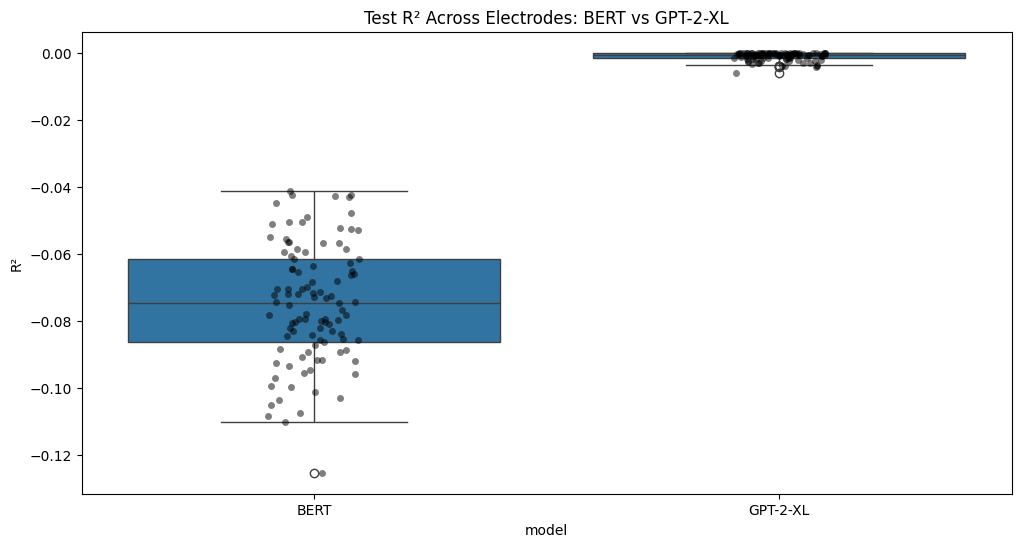

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.boxplot(x="model", y="test_R2", data=all_results)
sns.stripplot(x="model", y="test_R2", data=all_results, color="black", alpha=0.5, jitter=True)
plt.title("Test R² Across Electrodes: BERT vs GPT-2-XL")
plt.ylabel("R²")
plt.show()

#Examine why gpt has such low explainability for this data


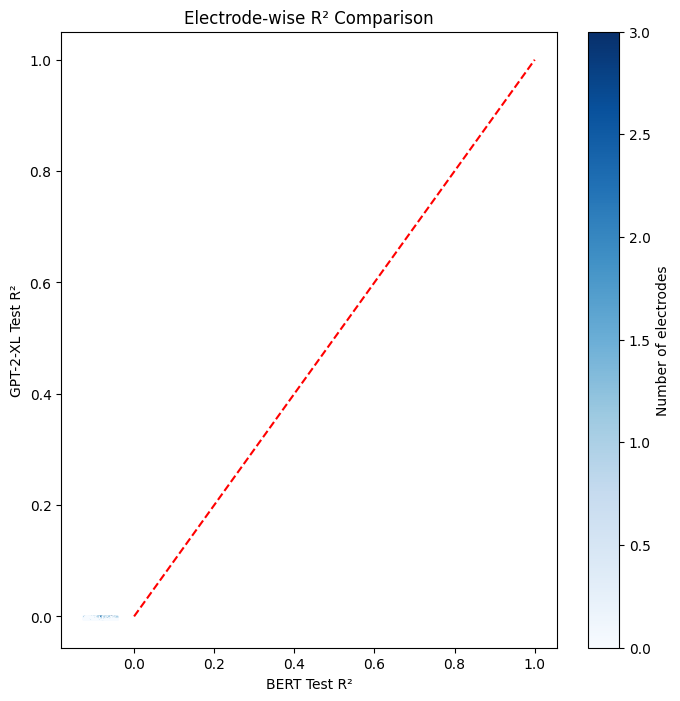

In [55]:
import matplotlib.pyplot as plt
# Pivot to get BERT vs GPT side by side
merged = all_results.pivot(index="electrode", columns="model", values="test_R2").reset_index()
merged.columns.name = None  # remove multiindex

# Now merged has columns: ['electrode', 'BERT', 'GPT-2-XL']

plt.figure(figsize=(8,8))
plt.hexbin(merged["BERT"], merged["GPT-2-XL"], gridsize=30, cmap="Blues")
plt.colorbar(label="Number of electrodes")
plt.plot([0,1],[0,1], "r--")  # y=x reference line
plt.xlabel("BERT Test R²")
plt.ylabel("GPT-2-XL Test R²")
plt.title("Electrode-wise R² Comparison")
plt.show()


In [56]:
#Lets try random forest
"""import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm

def rf_per_electrode(X, y, model_name, n_estimators=100, max_depth=None, random_state=42):
    """
    Fit Random Forest regression per electrode and compute metrics.
    """
    n_electrodes = y.shape[1]

    # --- Train/test split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, shuffle=True
    )

    results = []

    for i in tqdm(range(n_electrodes), desc=f"Running RF for {model_name}"):
        y_train_i = y_train[:, i]
        y_test_i = y_test[:, i]

        # Fit Random Forest
        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            n_jobs=-1,  # parallelize trees
            random_state=random_state
        )
        rf.fit(X_train, y_train_i)

        # Predictions
        y_pred_train = rf.predict(X_train)
        y_pred_test = rf.predict(X_test)

        # Metrics
        mse_train = mean_squared_error(y_train_i, y_pred_train)
        mse_test = mean_squared_error(y_test_i, y_pred_test)
        r2_train = r2_score(y_train_i, y_pred_train)
        r2_test = r2_score(y_test_i, y_pred_test)

        results.append({
            "electrode": f"electrode_{i}",
            "train_MSE": mse_train,
            "test_MSE": mse_test,
            "train_R2": r2_train,
            "test_R2": r2_test
        })

    results_df = pd.DataFrame(results)
    results_df["model"] = model_name
    print(f"{model_name}: Completed RF regression for {n_electrodes} electrodes.")
    return results_df"""

In [57]:
"""rf_bert_results_random_forest = rf_per_electrode(bert_embeddings, y, "RF-BERT", n_estimators=100)
rf_gpt_results_random_forest = rf_per_electrode(gpt_embeddings, y, "RF-GPT", n_estimators=100)"""


Running RF for RF-BERT:   7%|▋         | 7/102 [04:44<1:04:15, 40.59s/it]


KeyboardInterrupt: 

In [ ]:
#Other models I can try <- LLama 2, Gemini, 